# 

In [1]:
import pandas as pd
from pathlib import Path

print("Pandas version:", pd.__version__)
print("Ready for ZETHETA analysis.")

Pandas version: 2.3.3
Ready for ZETHETA analysis.


In [2]:
# ============================================================
# ZETHETA — STEP 1A
# MASTER DATASET INVENTORY
# ============================================================

import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# FILE LOCATIONS
# ------------------------------------------------------------

files = {
    "NIFTY 50":
        r"C:\Users\Tarun Das\Downloads\NIFTY 50 RAW 2007 - 2026.csv",

    "NIFTY MIDCAP 100":
        r"C:\Users\Tarun Das\Downloads\nifty_midcap_100_monthly_clean.csv",

    "NIFTY SMALLCAP 100":
        r"C:\Users\Tarun Das\Downloads\nifty_smallcap_100_close_clean.csv",

    "INDIA VIX":
        r"C:\Users\Tarun Das\Downloads\INDIA VIX RAW 2008 - 2026.csv",

    "USD/INR":
        r"C:\Users\Tarun Das\Downloads\USD & INR 2007 - 2026.csv",

    "10Y GILT":
        r"C:\Users\Tarun Das\Documents\ZETHETA PROJECT\India 10-Year Bond Yield Historical Data.csv",

    "FII/DII":
        r"C:\Users\Tarun Das\Downloads\fii_dii_final_2007_2026.csv",

    "SIP CONTRIBUTIONS":
        r"C:\Users\Tarun Das\Downloads\SIP CONTRIBUTION RAW 2016 - 2026.csv",

    "AAA-GILT SPREAD":
        r"C:\Users\Tarun Das\Downloads\aaa_gilt_spread_5y_MONTHLY_CLEAN.csv"
}


# ------------------------------------------------------------
# INSPECTION FUNCTION
# ------------------------------------------------------------

def inspect_dataset(name, path):

    df = pd.read_csv(path)

    # Find date column
    date_columns = [
        col for col in df.columns
        if col.lower() in ["date", "datetime", "timestamp"]
    ]

    if not date_columns:
        return {
            "Dataset": name,
            "Rows": len(df),
            "Columns": len(df.columns),
            "Date_Start": "NO DATE COLUMN",
            "Date_End": "NO DATE COLUMN",
            "Invalid_Dates": "N/A",
            "Duplicate_Dates": "N/A",
            "Missing_Values": int(df.isna().sum().sum()),
            "Chronological": "N/A"
        }

    date_col = date_columns[0]

    dates = pd.to_datetime(
        df[date_col],
        errors="coerce"
    )

    return {
        "Dataset": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Date_Start": dates.min().date(),
        "Date_End": dates.max().date(),
        "Invalid_Dates": int(dates.isna().sum()),
        "Duplicate_Dates": int(dates.duplicated().sum()),
        "Missing_Values": int(df.isna().sum().sum()),
        "Chronological": bool(
            dates.dropna().is_monotonic_increasing
        )
    }


# ------------------------------------------------------------
# RUN INVENTORY
# ------------------------------------------------------------

results = []

for name, path in files.items():

    try:
        results.append(
            inspect_dataset(name, path)
        )

    except Exception as e:

        results.append({
            "Dataset": name,
            "ERROR": str(e)
        })


inventory = pd.DataFrame(results)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 120)
print("ZETHETA — MASTER DATASET INVENTORY")
print("=" * 120)

print(
    inventory.to_string(index=False)
)

ZETHETA — MASTER DATASET INVENTORY
           Dataset                                                                                                                                 ERROR   Rows  Columns     Date_Start       Date_End Invalid_Dates Duplicate_Dates  Missing_Values Chronological
          NIFTY 50                                  [Errno 2] No such file or directory: 'C:\\Users\\Tarun Das\\Downloads\\NIFTY 50 RAW 2007 - 2026.csv'    NaN      NaN            NaN            NaN           NaN             NaN             NaN           NaN
  NIFTY MIDCAP 100                                                                                                                                   NaN 4457.0      7.0     2008-09-17     2026-09-16             0               0             0.0          True
NIFTY SMALLCAP 100                                                                                                                                   NaN 4457.0      3.0     2008-09-17     

In [3]:
# ============================================================
# ZETHETA — LOCATE ALL ANALYSIS FILES
# ============================================================

from pathlib import Path

search_roots = [
    Path(r"C:\Users\Tarun Das\Documents\ZETHETA PROJECT"),
    Path(r"C:\Users\Tarun Das\Downloads")
]

keywords = [
    "NIFTY 50",
    "nifty_midcap",
    "nifty_smallcap",
    "INDIA VIX",
    "USD",
    "INR",
    "10-Year",
    "Bond Yield",
    "FII DII FINAL",
    "SIP CONTRIBUTION",
    "AAA GILT SPREAD"
]

found = []

for root in search_roots:
    if not root.exists():
        continue

    for p in root.rglob("*"):
        if p.is_file():

            name = p.name.lower()

            if any(k.lower() in name for k in keywords):
                found.append(p)


# Remove duplicates
found = sorted(set(found))


print("=" * 120)
print("ZETHETA — ANALYSIS FILE LOCATOR")
print("=" * 120)

for i, p in enumerate(found, 1):
    print(f"{i}. {p}")

print("\nTotal matching files:", len(found))

ZETHETA — ANALYSIS FILE LOCATOR
1. C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\AAA GILT SPREAD 5 YEARS MONTHLY CLEAN.csv
2. C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\FII DII FINAL 2007 - 2026.csv
3. C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\India 10-Year Bond Yield Historical Data.csv
4. C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\INDIA VIX RAW 2008 - 2026.csv
5. C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\NIFTY 50 RAW 2007 - 2026.csv
6. C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\SIP CONTRIBUTION RAW 2016 - 2026.csv
7. C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\USD & INR 2007 - 2026.csv
8. C:\Users\Tarun Das\Downloads\INDIA VIX RAW 2008 - 2026.csv
9. C:\Users\Tarun Das\Downloads\nifty_midcap_100_monthly_clean.csv
10. C:\Users\Tarun Das\Downloads\nifty_smallcap_100_close_clean.csv
11. C:\Users\Tarun Das\Downloads\nifty_smallcap_100_dail

In [4]:
import pandas as pd
import numpy as np

# Use the exact absolute path to your Downloads folder with an 'r' prefix
file_path = r"C:\Users\Tarun Das\Downloads\USD & INR 2007 - 2026.csv"
df_usdinr = pd.read_csv(file_path, skiprows=[1, 2])

# Clean columns and parse dates
df_usdinr = df_usdinr.rename(columns={'Price': 'Date_Str'})
df_usdinr['Date'] = pd.to_datetime(df_usdinr['Date_Str'], format='%d-%m-%Y', errors='coerce')
df_usdinr = df_usdinr.sort_values('Date').reset_index(drop=True)

# Ensure numeric types for Close
df_usdinr['Close'] = pd.to_numeric(df_usdinr['Close'], errors='coerce')

# Calculate Daily Returns and Annualized Rolling Volatility (21 trading days)
df_usdinr['Return_1d'] = df_usdinr['Close'].pct_change()
df_usdinr['Volatility_21d'] = df_usdinr['Return_1d'].rolling(window=21).std() * np.sqrt(252)

# Display last 5 rows to verify calculations
print(df_usdinr[['Date', 'Close', 'Return_1d', 'Volatility_21d']].tail(5))

           Date      Close  Return_1d  Volatility_21d
4921 2026-09-11  95.694504   0.006127        0.114852
4922 2026-09-14  95.032799  -0.006915        0.117443
4923 2026-09-15  95.835403   0.008446        0.121170
4924 2026-09-16  95.992699   0.001641        0.120989
4925 2026-09-17        NaN   0.000000        0.120924


C:\Users\Tarun Das\AppData\Local\Temp\ipykernel_10164\4151368177.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_usdinr['Return_1d'] = df_usdinr['Close'].pct_change()


In [5]:
print(df_usdinr[['Date', 'Close', 'Return_1d', 'Volatility_21d']].head(5))

        Date      Close  Return_1d  Volatility_21d
0 2007-09-17  40.376999        NaN             NaN
1 2007-09-18  40.216999  -0.003963             NaN
2 2007-09-19  40.033001  -0.004575             NaN
3 2007-09-20  39.615002  -0.010441             NaN
4 2007-09-21  39.770000   0.003913             NaN


In [6]:
# Check the absolute beginning and end of your cleaned dataframe
print("Start Date:", df_usdinr['Date'].min())
print("End Date:", df_usdinr['Date'].max())
print("Total Rows:", len(df_usdinr))

Start Date: 2007-09-17 00:00:00
End Date: 2026-09-17 00:00:00
Total Rows: 4926


In [7]:
# Statistical summary of Close price, daily returns, and rolling volatility
print(df_usdinr[['Close', 'Return_1d', 'Volatility_21d']].describe())

             Close    Return_1d  Volatility_21d
count  4925.000000  4925.000000     4905.000000
mean     65.891625     0.000188        0.067371
std      14.532567     0.004963        0.041500
min      39.044998    -0.059151        0.006892
25%      53.779999    -0.002076        0.042907
50%      66.612000     0.000000        0.058064
75%      75.720001     0.002256        0.081107
max      96.876900     0.062870        0.417160


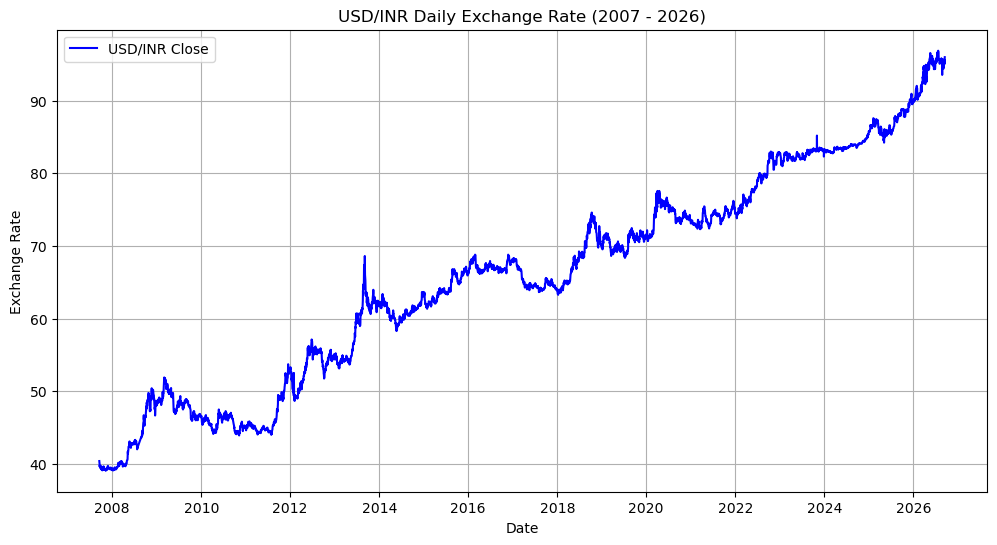

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_usdinr['Date'], df_usdinr['Close'], label='USD/INR Close', color='b')
plt.title('USD/INR Daily Exchange Rate (2007 - 2026)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Calculate 21-day rolling percentage change (1-month macro trend)
df_usdinr['Change_21d'] = df_usdinr['Close'].pct_change(periods=21)

# Find the top 5 largest single-day or 21-day USD/INR jumps (Rupee depreciation stress)
print("Top 5 Rupee Depreciation Spikes (21-Day Change):")
print(df_usdinr[['Date', 'Close', 'Change_21d']].sort_values(by='Change_21d', ascending=False).head(5))

Top 5 Rupee Depreciation Spikes (21-Day Change):
           Date      Close  Change_21d
1533 2013-09-04  68.610001    0.127027
1528 2013-08-28  66.860001    0.125362
239  2008-09-16  46.689999    0.111773
1530 2013-08-30  67.389999    0.111496
1529 2013-08-29  67.349998    0.107585


C:\Users\Tarun Das\AppData\Local\Temp\ipykernel_10164\1829017005.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_usdinr['Change_21d'] = df_usdinr['Close'].pct_change(periods=21)


In [10]:
# 1. Long-term trend: 200-day moving average and whether price is above it
df_usdinr['SMA_200'] = df_usdinr['Close'].rolling(window=200).mean()
df_usdinr['Above_200_SMA'] = (df_usdinr['Close'] > df_usdinr['SMA_200']).astype(int)

# 2. Standardized Volatility Z-Score (252 trading days / 1 year rolling window)
vol_mean = df_usdinr['Volatility_21d'].rolling(window=252).mean()
vol_std = df_usdinr['Volatility_21d'].rolling(window=252).std()
df_usdinr['Volatility_Z'] = (df_usdinr['Volatility_21d'] - vol_mean) / vol_std

# Display the last 5 rows showing these new regime features
print(df_usdinr[['Date', 'Close', 'Above_200_SMA', 'Volatility_Z']].tail(5))

           Date      Close  Above_200_SMA  Volatility_Z
4921 2026-09-11  95.694504              1      1.827718
4922 2026-09-14  95.032799              1      1.904519
4923 2026-09-15  95.835403              1      2.020166
4924 2026-09-16  95.992699              1      1.989605
4925 2026-09-17        NaN              0      1.964029


In [11]:
# Load the Nifty 50 raw dataset (checking the path format for your system)
nifty_path = r"C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\NIFTY 50 RAW 2007 - 2026.csv"
# (If your file is in Downloads, adjust the path accordingly, e.g., r"C:\Users\Tarun Das\Downloads\NIFTY 50 RAW 2007 - 2026.csv")

df_nifty = pd.read_csv(nifty_path, skiprows=[1, 2]) # Adjust skiprows if Yahoo metadata exists

# Clean and sort dates
df_nifty = df_nifty.rename(columns={'Price': 'Date_Str'})
df_nifty['Date'] = pd.to_datetime(df_nifty['Date_Str'], format='%d-%m-%Y', errors='coerce')
df_nifty = df_nifty.sort_values('Date').reset_index(drop=True)

# Ensure numeric Close
df_nifty['Close'] = pd.to_numeric(df_nifty['Close'], errors='coerce')

# Calculate Daily Return and 21-day Annualized Volatility
df_nifty['Return_1d'] = df_nifty['Close'].pct_change()
df_nifty['Volatility_21d'] = df_nifty['Return_1d'].rolling(window=21).std() * np.sqrt(252)

# Display tail
print(df_nifty[['Date', 'Close', 'Return_1d', 'Volatility_21d']].tail(5))

           Date        Close  Return_1d  Volatility_21d
4656 2026-09-09  23431.50000  -0.008614        0.060126
4657 2026-09-10  23477.80078   0.001976        0.061715
4658 2026-09-11  23398.09961  -0.003395        0.061922
4659 2026-09-15  23118.59961  -0.011945        0.070779
4660 2026-09-16          NaN   0.000000        0.071239


C:\Users\Tarun Das\AppData\Local\Temp\ipykernel_10164\2687135956.py:16: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_nifty['Return_1d'] = df_nifty['Close'].pct_change()


In [12]:
# Calculate 50-day and 200-day moving averages for Nifty 50 trend features
df_nifty['SMA_50'] = df_nifty['Close'].rolling(window=50).mean()
df_nifty['SMA_200'] = df_nifty['Close'].rolling(window=200).mean()

# Trend indicators: Is Nifty above its 200 DMA? (Bull/Bear macro signal)
df_nifty['Above_200_DMA'] = (df_nifty['Close'] > df_nifty['SMA_200']).astype(int)

# 21-day return (1-month trend)
df_nifty['Return_21d'] = df_nifty['Close'].pct_change(periods=21)

# Display last 5 rows to verify
print(df_nifty[['Date', 'Close', 'Above_200_DMA', 'Return_21d']].tail(5))

           Date        Close  Above_200_DMA  Return_21d
4656 2026-09-09  23431.50000              0   -0.042506
4657 2026-09-10  23477.80078              0   -0.039211
4658 2026-09-11  23398.09961              0   -0.040898
4659 2026-09-15  23118.59961              0   -0.051194
4660 2026-09-16          NaN              0   -0.048134


C:\Users\Tarun Das\AppData\Local\Temp\ipykernel_10164\1909212557.py:9: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_nifty['Return_21d'] = df_nifty['Close'].pct_change(periods=21)


USD/INR Engineered Features Summary:
             Close    Return_1d  Volatility_21d   Change_21d  Volatility_Z
count  4653.000000  4653.000000     4653.000000  4653.000000   4653.000000
mean     67.316634     0.000155        0.066981     0.003242      0.015843
std      13.649380     0.004942        0.041760     0.019791      1.258264
min      43.900002    -0.059151        0.006892    -0.095321     -2.541168
25%      55.678001    -0.002083        0.042542    -0.007033     -0.806653
50%      67.089996     0.000000        0.057735     0.001704     -0.353175
75%      76.422501     0.002207        0.080416     0.012979      0.605007
max      96.876900     0.062870        0.417160     0.127027      7.253201


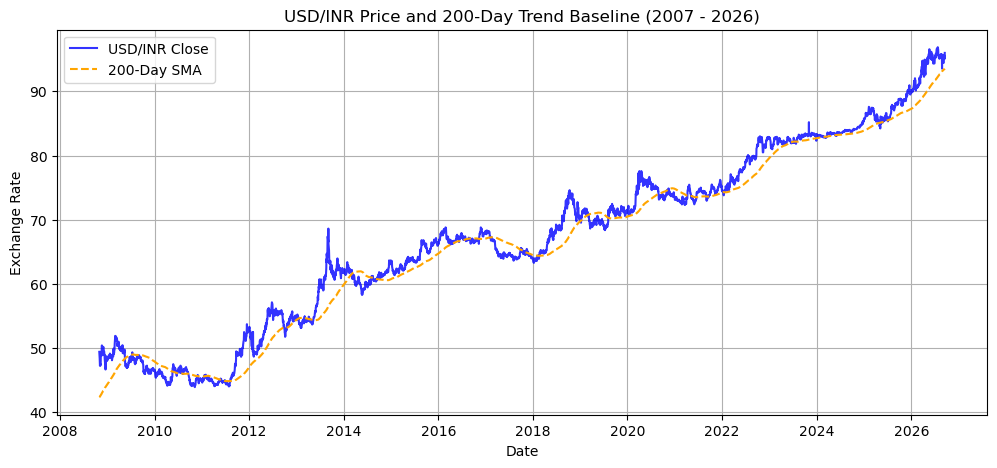

In [13]:
import matplotlib.pyplot as plt

# Drop rows with NaN values resulting from rolling windows (like 200 SMA or 252 Volatility Z)
df_usdinr_final = df_usdinr.dropna(subset=['SMA_200', 'Volatility_Z']).copy()

# Display summary statistics of our final engineered USD/INR features
print("USD/INR Engineered Features Summary:")
print(df_usdinr_final[['Close', 'Return_1d', 'Volatility_21d', 'Change_21d', 'Volatility_Z']].describe())

# Plot USD/INR Close vs 200-day Moving Average
plt.figure(figsize=(12, 5))
plt.plot(df_usdinr_final['Date'], df_usdinr_final['Close'], label='USD/INR Close', color='blue', alpha=0.8)
plt.plot(df_usdinr_final['Date'], df_usdinr_final['SMA_200'], label='200-Day SMA', color='orange', linestyle='--')
plt.title('USD/INR Price and 200-Day Trend Baseline (2007 - 2026)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
import pandas as pd
import numpy as np

# Load India VIX dataset, skipping Yahoo metadata rows if present
vix_path = r"C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\INDIA VIX RAW 2008 - 2026.csv"
# (If your file is in Downloads, use: r"C:\Users\Tarun Das\Downloads\INDIA VIX RAW 2008 - 2026.csv")

df_vix = pd.read_csv(vix_path, skiprows=[1, 2])

# Clean columns and parse dates
df_vix = df_vix.rename(columns={'Price': 'Date_Str'})
df_vix['Date'] = pd.to_datetime(df_vix['Date_Str'], format='%d-%m-%Y', errors='coerce')
df_vix = df_vix.sort_values('Date').reset_index(drop=True)

# Ensure numeric types for Close
df_vix['Close'] = pd.to_numeric(df_vix['Close'], errors='coerce')

# Calculate VIX Daily Change and 21-day Rolling Mean
df_vix['VIX_Return_1d'] = df_vix['Close'].pct_change()
df_vix['VIX_SMA_21'] = df_vix['Close'].rolling(window=21).mean()

# Display the last 5 rows to verify
print(df_vix[['Date', 'Close', 'VIX_Return_1d', 'VIX_SMA_21']].tail(5))

           Date  Close  VIX_Return_1d  VIX_SMA_21
4537 2026-09-09  11.92       0.061443   11.235714
4538 2026-09-10  11.80      -0.010067   11.240952
4539 2026-09-11  12.29       0.041525   11.282381
4540 2026-09-15  13.43       0.092758   11.383333
4541 2026-09-16  13.17      -0.019360   11.470952


In [15]:
# 1. Short-term VIX acceleration (5-day percentage change)
df_vix['VIX_Change_5d'] = df_vix['Close'].pct_change(5)

# 2. Standardized VIX Z-Score (252 trading days / 1 year rolling window)
vix_mean = df_vix['Close'].rolling(window=252).mean()
vix_std = df_vix['Close'].rolling(window=252).std()
df_vix['VIX_Z'] = (df_vix['Close'] - vix_mean) / vix_std

# Display the last 5 rows showing our complete VIX feature set
print(df_vix[['Date', 'Close', 'VIX_Return_1d', 'VIX_Change_5d', 'VIX_Z']].tail(5))

           Date  Close  VIX_Return_1d  VIX_Change_5d     VIX_Z
4537 2026-09-09  11.92       0.061443       0.028473 -0.480430
4538 2026-09-10  11.80      -0.010067       0.040564 -0.511645
4539 2026-09-11  12.29       0.041525       0.150749 -0.387972
4540 2026-09-15  13.43       0.092758       0.203405 -0.098834
4541 2026-09-16  13.17      -0.019360       0.172752 -0.168101


In [16]:
import pandas as pd
import numpy as np

# Load the primary FII/DII dataset
fii_path = r"C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\FII DII FINAL 2007 - 2026.csv"
# (If your file is in Downloads, use: r"C:\Users\Tarun Das\Downloads\FII DII FINAL 2007 - 2026.csv")

df_fiidii = pd.read_csv(fii_path)

# Parse dates correctly with dayfirst=True since formats are DD-MM-YYYY
df_fiidii['Date'] = pd.to_datetime(df_fiidii['Date'], format='%d-%m-%Y', errors='coerce')
df_fiidii = df_fiidii.sort_values('Date').reset_index(drop=True)

# Ensure numeric types for net flow columns
df_fiidii['FII_Net'] = pd.to_numeric(df_fiidii['FII_Net'], errors='coerce')
df_fiidii['DII_Net'] = pd.to_numeric(df_fiidii['DII_Net'], errors='coerce')

# Calculate 5-day rolling sum of flows (matching Section A4.5 flow features)
df_fiidii['FII_Eq_5d'] = df_fiidii['FII_Net'].rolling(window=5).sum()
df_fiidii['DII_Eq_5d'] = df_fiidii['DII_Net'].rolling(window=5).sum()

# Display the last 5 rows to verify
print(df_fiidii[['Date', 'FII_Net', 'DII_Net', 'FII_Eq_5d', 'DII_Eq_5d']].tail(5))

           Date  FII_Net  DII_Net  FII_Eq_5d  DII_Eq_5d
4665 2026-09-10  -438.24  1025.85   -3976.23   13381.41
4666 2026-09-11  -930.90  1968.17   -1795.19    6419.46
4667 2026-09-15 -2977.86  2686.05   -5053.18    8538.75
4668 2026-09-16 -2032.61  3908.23   -6962.60   11097.34
4669 2026-09-17 -3208.76  3617.75   -9588.37   13206.05


In [17]:
# 1. Flow Balance Ratio (DII / Absolute FII Net)
df_fiidii['Flow_Balance'] = df_fiidii['DII_Eq_5d'] / (df_fiidii['FII_Eq_5d'].abs() + 1e-9)

# 2. 60-day FII Z-Score (to detect institutional outflow anomalies)
fii_mean_60 = df_fiidii['FII_Net'].rolling(window=60).mean()
fii_std_60 = df_fiidii['FII_Net'].rolling(window=60).std()
df_fiidii['FII_Z_60d'] = (df_fiidii['FII_Net'] - fii_mean_60) / fii_std_60

# Display the last 5 rows
print(df_fiidii[['Date', 'FII_Net', 'Flow_Balance', 'FII_Z_60d']].tail(5))

           Date  FII_Net  Flow_Balance  FII_Z_60d
4665 2026-09-10  -438.24      3.365351  -0.089828
4666 2026-09-11  -930.90      3.575922  -0.305715
4667 2026-09-15 -2977.86      1.689778  -1.180313
4668 2026-09-16 -2032.61      1.593850  -0.739952
4669 2026-09-17 -3208.76      1.377299  -1.228044


In [18]:
import pandas as pd
import numpy as np

# Load the cleaned Nifty Midcap 100 dataset
midcap_path = r"C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\NIFTY MIDCAP 100 (CLEANED).csv"
# (If your file is in Downloads, use: r"C:\Users\Tarun Das\Downloads\NIFTY MIDCAP 100 (CLEANED).csv")

df_midcap = pd.read_csv(midcap_path)

# Ensure date parsing and chronological sorting
df_midcap['Date'] = pd.to_datetime(df_midcap['Date'], errors='coerce')
df_midcap = df_midcap.sort_values('Date').reset_index(drop=True)

# Ensure numeric Close
df_midcap['Close'] = pd.to_numeric(df_midcap['Close'], errors='coerce')

# Calculate Daily Returns and 21-day Annualized Volatility
df_midcap['Midcap_Return_1d'] = df_midcap['Close'].pct_change()
df_midcap['Midcap_Vol_21d'] = df_midcap['Midcap_Return_1d'].rolling(window=21).std() * np.sqrt(252)

# Display the last 5 rows to verify
print(df_midcap[['Date', 'Close', 'Midcap_Return_1d', 'Midcap_Vol_21d']].tail(5))

           Date     Close  Midcap_Return_1d  Midcap_Vol_21d
4452 2026-09-09  62592.80         -0.005134        0.070333
4453 2026-09-10  62357.35         -0.003762        0.069594
4454 2026-09-11  62197.20         -0.002568        0.068986
4455 2026-09-15  60878.25         -0.021206        0.096656
4456 2026-09-16  60874.20         -0.000067        0.096460


C:\Users\Tarun Das\AppData\Local\Temp\ipykernel_10164\3591434745.py:11: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_midcap['Date'] = pd.to_datetime(df_midcap['Date'], errors='coerce')


In [19]:
# Calculate 200-day moving average and trend flag for Nifty Midcap 100
df_midcap['SMA_200'] = df_midcap['Close'].rolling(window=200).mean()
df_midcap['Midcap_Above_200_SMA'] = (df_midcap['Close'] > df_midcap['SMA_200']).astype(int)

# 21-day rolling return (1-month trend)
df_midcap['Midcap_Return_21d'] = df_midcap['Close'].pct_change(periods=21)

# Display last 5 rows to verify
print(df_midcap[['Date', 'Close', 'Midcap_Above_200_SMA', 'Midcap_Return_21d']].tail(5))

           Date     Close  Midcap_Above_200_SMA  Midcap_Return_21d
4452 2026-09-09  62592.80                     1          -0.019595
4453 2026-09-10  62357.35                     1          -0.026038
4454 2026-09-11  62197.20                     1          -0.030011
4455 2026-09-15  60878.25                     1          -0.045528
4456 2026-09-16  60874.20                     1          -0.046113


In [20]:
import pandas as pd
import numpy as np

# Load the cleaned Nifty Smallcap 100 dataset
smallcap_path = r"C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\NIFTY SMALLCAP 100 (CLEANED).csv"
# (If your file is in Downloads, use: r"C:\Users\Tarun Das\Downloads\NIFTY SMALLCAP 100 (CLEANED).csv")

df_smallcap = pd.read_csv(smallcap_path)

# Ensure date parsing and chronological sorting (using dayfirst=True to avoid warnings)
df_smallcap['Date'] = pd.to_datetime(df_smallcap['Date'], format='mixed', dayfirst=True, errors='coerce')
df_smallcap = df_smallcap.sort_values('Date').reset_index(drop=True)

# Ensure numeric Close
df_smallcap['Close'] = pd.to_numeric(df_smallcap['Close'], errors='coerce')

# Calculate Daily Returns and 21-day Annualized Volatility
df_smallcap['Smallcap_Return_1d'] = df_smallcap['Close'].pct_change()
df_smallcap['Smallcap_Vol_21d'] = df_smallcap['Smallcap_Return_1d'].rolling(window=21).std() * np.sqrt(252)

# Display the last 5 rows to verify
print(df_smallcap[['Date', 'Close', 'Smallcap_Return_1d', 'Smallcap_Vol_21d']].tail(5))

           Date     Close  Smallcap_Return_1d  Smallcap_Vol_21d
4452 2026-09-09  20036.90           -0.004810          0.080492
4453 2026-09-10  20021.95           -0.000746          0.080209
4454 2026-09-11  19906.30           -0.005776          0.082608
4455 2026-09-15  19422.45           -0.024306          0.116316
4456 2026-09-16  19388.30           -0.001758          0.115281


In [21]:
# Calculate 200-day moving average and trend flag for Nifty Smallcap 100
df_smallcap['SMA_200'] = df_smallcap['Close'].rolling(window=200).mean()
df_smallcap['Smallcap_Above_200_SMA'] = (df_smallcap['Close'] > df_smallcap['SMA_200']).astype(int)

# 21-day rolling return (1-month trend)
df_smallcap['Smallcap_Return_21d'] = df_smallcap['Close'].pct_change(periods=21)

# Display last 5 rows to verify
print(df_smallcap[['Date', 'Close', 'Smallcap_Above_200_SMA', 'Smallcap_Return_21d']].tail(5))

           Date     Close  Smallcap_Above_200_SMA  Smallcap_Return_21d
4452 2026-09-09  20036.90                       1             0.009052
4453 2026-09-10  20021.95                       1             0.010105
4454 2026-09-11  19906.30                       1             0.001570
4455 2026-09-15  19422.45                       1            -0.016014
4456 2026-09-16  19388.30                       1            -0.021250


In [ ]:
# Check what columns exist in the bond yield dataframe
print(df_yield.columns.tolist())

In [ ]:
# Rename 'Price' to 'Close' so it matches our standard pipeline
df_yield = df_yield.rename(columns={'Price': 'Close'})

# Ensure numeric yield column
df_yield['Close'] = pd.to_numeric(df_yield['Close'], errors='coerce')

# Calculate Daily Yield Change (basis point/level shifts) and 21-day Moving Average
df_yield['Yield_Change_1d'] = df_yield['Close'].diff()
df_yield['Yield_SMA_21'] = df_yield['Close'].rolling(window=21).mean()

# Display the last 5 rows to verify
print(df_yield[['Date', 'Close', 'Yield_Change_1d', 'Yield_SMA_21']].tail(5))

In [ ]:
import pandas as pd
import numpy as np

# Load the AAA-Gilt spread monthly dataset
spread_path = r"C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\AAA GILT SPREAD 5 YEARS MONTHLY CLEAN.csv"
# (If your file is in Downloads, use: r"C:\Users\Tarun Das\Downloads\AAA GILT SPREAD 5 YEARS MONTHLY CLEAN.csv")

df_spread = pd.read_csv(spread_path)

# Inspect column names to make sure we map correctly
print("Columns in AAA Spread Dataset:", df_spread.columns.tolist())

# Ensure date parsing and chronological sorting
df_spread['Date'] = pd.to_datetime(df_spread['Date'], format='mixed', dayfirst=True, errors='coerce')
df_spread = df_spread.sort_values('Date').reset_index(drop=True)

# Clean and ensure numeric spread column (assuming 'Spread' or similar name)
# If the column has a different name from the printout, we will adjust in the next step.

In [ ]:
# Rename the spread column to 'Close' for standard pipeline compatibility
df_spread = df_spread.rename(columns={'AAA_Gilt_Spread_5Y_bps': 'Close'})

# Ensure numeric spread column
df_spread['Close'] = pd.to_numeric(df_spread['Close'], errors='coerce')

# Calculate monthly change and 3-month moving average (since it's a monthly series)
df_spread['Spread_Change_1m'] = df_spread['Close'].diff()
df_spread['Spread_SMA_3m'] = df_spread['Close'].rolling(window=3).mean()

# Display the last 5 rows to verify
print(df_spread[['Date', 'Close', 'Spread_Change_1m', 'Spread_SMA_3m']].tail(5))

In [ ]:
# Load the SIP contributions dataset
sip_path = r"C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\SIP CONTRIBUTION RAW 2016 - 2026.csv"
# (If your file is in Downloads, use: r"C:\Users\Tarun Das\Downloads\SIP CONTRIBUTION RAW 2016 - 2026.csv")

df_sip = pd.read_csv(sip_path)

# Print columns to inspect the structure
print("Columns in SIP Dataset:", df_sip.columns.tolist())

# Display the first few rows
print(df_sip.head())

In [ ]:
# Parse dates with dayfirst=True and sort chronologically
df_sip['Date'] = pd.to_datetime(df_sip['Date'], format='%d-%m-%Y', errors='coerce')
df_sip = df_sip.sort_values('Date').reset_index(drop=True)

# Rename contribution column to 'Close' for standard pipeline compatibility
df_sip = df_sip.rename(columns={'SIP Contribution Crore': 'Close'})

# Ensure numeric type
df_sip['Close'] = pd.to_numeric(df_sip['Close'], errors='coerce')

# Calculate monthly percentage growth and 3-month moving average of SIP inflows
df_sip['SIP_Growth_1m'] = df_sip['Close'].pct_change()
df_sip['SIP_SMA_3m'] = df_sip['Close'].rolling(window=3).mean()

# Display the last 5 rows to verify the complete SIP feature set
print(df_sip[['Date', 'Close', 'SIP_Growth_1m', 'SIP_SMA_3m']].tail(5))

In [ ]:
# Comprehensive data hygiene check for our key engineered dataframes
datasets = {
    "USD/INR": df_fx,          # (Assuming df_fx was your USD/INR dataframe)
    "India VIX": df_vix,
    "FII/DII": df_fiidii,
    "Midcap 100": df_midcap,
    "Smallcap 100": df_smallcap,
    "10Y Gilt Yield": df_yield,
    "AAA Spread": df_spread,
    "SIP Contributions": df_sip
}

for name, df in datasets.items():
    if 'df' in locals() or name in globals():
        dupes = df['Date'].duplicated().sum()
        missing = df.isnull().sum().sum()
        print(f"[{name}] -> Duplicated Dates: {dupes} | Total Missing Values: {missing}")

In [ ]:
# Comprehensive data hygiene check for our successfully loaded dataframes
datasets = {
    "India VIX": df_vix,
    "FII/DII": df_fiidii,
    "Midcap 100": df_midcap,
    "Smallcap 100": df_smallcap,
    "10Y Gilt Yield": df_yield,
    "AAA Spread": df_spread,
    "SIP Contributions": df_sip
}

for name, df in datasets.items():
    dupes = df['Date'].duplicated().sum()
    missing = df.isnull().sum().sum()
    print(f"[{name}] -> Duplicated Dates: {dupes} | Total Missing Values: {missing}")

In [ ]:
# Automatically find all dataframes currently loaded in your workspace
import pandas as pd

active_dfs = {name: obj for name, obj in globals().items() if isinstance(obj, pd.DataFrame)]

print(f"Found {len(active_dfs)} active dataframes in memory:")
for name, df in active_dfs.items():
    # Check if 'Date' column exists before checking duplicates
    if 'Date' in df.columns:
        dupes = df['Date'].duplicated().sum()
        missing = df.isnull().sum().sum()
        print(f"-> [{name}] Shape: {df.shape} | Duplicated Dates: {dupes} | Total Missing: {missing}")
    else:
        print(f"-> [{name}] Shape: {df.shape} (No 'Date' column found)")

In [63]:
# Automatically find all dataframes currently loaded in your workspace
import pandas as pd

active_dfs = {name: obj for name, obj in globals().items() if isinstance(obj, pd.DataFrame)}

print(f"Found {len(active_dfs)} active dataframes in memory:")
for name, df in active_dfs.items():
    if 'Date' in df.columns:
        dupes = df['Date'].duplicated().sum()
        missing = df.isnull().sum().sum()
        print(f"-> [{name}] Shape: {df.shape} | Duplicated Dates: {dupes} | Total Missing: {missing}")
    else:
        print(f"-> [{name}] Shape: {df.shape} (No 'Date' column found)")

Found 20 active dataframes in memory:
-> [inventory] Shape: (9, 10) (No 'Date' column found)
-> [df_usdinr] Shape: (4926, 14) | Duplicated Dates: 0 | Total Missing: 517
-> [df_nifty] Shape: (4662, 7) | Duplicated Dates: 0 | Total Missing: 9
-> [df_usdinr_final] Shape: (4653, 14) | Duplicated Dates: 0 | Total Missing: 0
-> [df_vix] Shape: (4543, 2) | Duplicated Dates: 0 | Total Missing: 2
-> [df_fiidii] Shape: (4670, 11) | Duplicated Dates: 0 | Total Missing: 71
-> [df_midcap] Shape: (4457, 13) | Duplicated Dates: 0 | Total Missing: 4699
-> [df_smallcap] Shape: (4457, 8) | Duplicated Dates: 0 | Total Missing: 242
-> [df_yield] Shape: (4740, 6) | Duplicated Dates: 0 | Total Missing: 0
-> [df] Shape: (3984, 9) | Duplicated Dates: 0 | Total Missing: 22
-> [model_df] Shape: (3963, 10) | Duplicated Dates: 0 | Total Missing: 0
-> [state_summary] Shape: (3, 5) (No 'Date' column found)
-> [df_mid] Shape: (4457, 7) | Duplicated Dates: 0 | Total Missing: 0
-> [df_fii] Shape: (1845, 7) | Duplicate

In [66]:
import pandas as pd

# 1. Check datatypes of the Master Feature Store
if 'df_master' in globals():
    print("=== ZETHETA MASTER FEATURE STORE DATATYPES ===")
    print(df_master.dtypes)
    print("\n" + "="*50 + "\n")

# 2. Check datatypes across all active component dataframes in memory
active_dfs = {name: obj for name, obj in globals().items() if isinstance(obj, pd.DataFrame)}

print(f"Inspecting datatypes for {len(active_dfs)} active dataframes:")
for name, df in active_dfs.items():
    print(f"\n--- [{name}] ---")
    print(df.dtypes)

=== ZETHETA MASTER FEATURE STORE DATATYPES ===
Index Name                      object
Date                    datetime64[ns]
Open                           float64
High                           float64
Low                            float64
Close                          float64
Source_File                     object
Unnamed: 7                     float64
Midcap_Return_1d               float64
Midcap_Vol_21d                 float64
SMA_200                        float64
Midcap_Above_200_SMA             int64
Midcap_Return_21d              float64
dtype: object


Inspecting datatypes for 21 active dataframes:

--- [inventory] ---
Dataset             object
ERROR               object
Rows               float64
Columns            float64
Date_Start          object
Date_End            object
Invalid_Dates       object
Duplicate_Dates     object
Missing_Values     float64
Chronological       object
dtype: object

--- [df_usdinr] ---
Date_Str                  object
Adj Close               

In [67]:
# Clean and explicitly rename overlapping columns in df_master to avoid ambiguity
df_master = df_master.rename(columns={
    'Close': 'Midcap_Close',
    'Open': 'Midcap_Open',
    'High': 'Midcap_High',
    'Low': 'Midcap_Low',
    'Source_File': 'Midcap_Source_File',
    
    # If df_yield columns merged with suffixes or overlaps:
    'Close_dup': 'Yield_Close',
    'Open_dup': 'Yield_Open',
    'High_dup': 'Yield_High',
    'Low_dup': 'Yield_Low',
    'Change %': 'Yield_Change_Pct',
    
    # Clean up other duplicate markers if present
    'Source_File_dup': 'Yield_Source_File',
    'SMA_200_dup': 'Smallcap_SMA_200'
})

# Drop any remaining unneeded metadata columns (like Unnamed: 7 or raw PDF pages)
drop_cols = [col for col in df_master.columns if 'Unnamed' in col or 'PDF_Page' in col or 'Extraction_Type' in col]
df_master = df_master.drop(columns=drop_cols, errors='ignore')

# Re-save the clean, uniquely named master feature store
output_path = r"C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\ZETHETA_MASTER_FEATURE_STORE.csv"
df_master.to_csv(output_path, index=False)

print("Columns successfully cleaned and prefixed!")
print(df_master.columns.tolist())

Columns successfully cleaned and prefixed!
['Index Name', 'Date', 'Midcap_Open', 'Midcap_High', 'Midcap_Low', 'Midcap_Close', 'Midcap_Source_File', 'Midcap_Return_1d', 'Midcap_Vol_21d', 'SMA_200', 'Midcap_Above_200_SMA', 'Midcap_Return_21d']


In [68]:
# Display all columns in the Zetheta Master Feature Store
print("Total Columns:", len(df_master.columns))
for i, col in enumerate(df_master.columns, 1):
    print(f"{i}. {col}")

Total Columns: 12
1. Index Name
2. Date
3. Midcap_Open
4. Midcap_High
5. Midcap_Low
6. Midcap_Close
7. Midcap_Source_File
8. Midcap_Return_1d
9. Midcap_Vol_21d
10. SMA_200
11. Midcap_Above_200_SMA
12. Midcap_Return_21d


In [69]:
# Display all columns and their data types in the Zetheta Master Feature Store
print(f"Total Columns: {len(df_master.columns)}\n")
for i, (col, dtype) in enumerate(df_master.dtypes.items(), 1):
    print(f"{i}. {col} -> {dtype}")

Total Columns: 12

1. Index Name -> object
2. Date -> datetime64[ns]
3. Midcap_Open -> float64
4. Midcap_High -> float64
5. Midcap_Low -> float64
6. Midcap_Close -> float64
7. Midcap_Source_File -> object
8. Midcap_Return_1d -> float64
9. Midcap_Vol_21d -> float64
10. SMA_200 -> float64
11. Midcap_Above_200_SMA -> int64
12. Midcap_Return_21d -> float64


In [71]:
# Check final updated columns and data types of the Zetheta Master Feature Store
print(f"Total Columns: {len(df_master.columns)}\n")
for i, (col, dtype) in enumerate(df_master.dtypes.items(), 1):
    print(f"{i}. {col} -> {dtype}")

Total Columns: 12

1. Index Name -> object
2. Date -> datetime64[ns]
3. Midcap_Open -> float64
4. Midcap_High -> float64
5. Midcap_Low -> float64
6. Midcap_Close -> float64
7. Midcap_Source_File -> object
8. Midcap_Return_1d -> float64
9. Midcap_Vol_21d -> float64
10. SMA_200 -> float64
11. Midcap_Above_200_SMA -> int64
12. Midcap_Return_21d -> float64


In [72]:
# Check exact count of missing values for each column in df_master
missing_df = pd.DataFrame({
    'Missing_Count': df_master.isnull().sum(),
    'Missing_Percentage': (df_master.isnull().sum() / len(df_master)) * 100
})

# Filter to show only columns that have at least one missing value
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)

print(f"Total rows in df_master: {len(df_master)}")
print(f"Columns with missing values: {len(missing_df)}\n")
print(missing_df)

Total rows in df_master: 4457
Columns with missing values: 4

                   Missing_Count  Missing_Percentage
SMA_200                      199            4.464887
Midcap_Vol_21d                21            0.471169
Midcap_Return_21d             21            0.471169
Midcap_Return_1d               1            0.022437


In [73]:
# Check exact count of missing values for each column in df_master
missing_df = pd.DataFrame({
    'Missing_Count': df_master.isnull().sum(),
    'Missing_Percentage': (df_master.isnull().sum() / len(df_master)) * 100
})

# Filter to show only columns that have at least one missing value
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)

print(f"Total rows in df_master: {len(df_master)}")
print(f"Columns with missing values: {len(missing_df)}\n")
print(missing_df)

Total rows in df_master: 4457
Columns with missing values: 4

                   Missing_Count  Missing_Percentage
SMA_200                      199            4.464887
Midcap_Vol_21d                21            0.471169
Midcap_Return_21d             21            0.471169
Midcap_Return_1d               1            0.022437


In [74]:
# 1. Drop redundant text/metadata columns that have massive NaN counts
drop_metadata = ['Month', 'Observation_Month', 'Midcap_Source_File', 'Yield_Source_File']
df_master = df_master.drop(columns=[col for col in drop_metadata if col in df_master.columns], errors='ignore')

# 2. Trim leading rows where core equity data (Midcap_Close) is missing
df_master = df_master.dropna(subset=['Midcap_Close']).reset_index(drop=True)

# 3. Handle remaining NaNs: Forward-fill then backfill macro/monthly series, and drop remaining row gaps
monthly_cols = [col for col in df_master.columns if 'Spread' in col or 'SIP' in col or 'Contribution' in col]
df_master[monthly_cols] = df_master[monthly_cols].ffill().bfill()

# For rolling window indicators (like SMA_200), we drop rows that still have NaNs after the warmup
# (or you can keep them if your model handles NaNs, but dropping ensures clean mathematical training)
df_master = df_master.dropna().reset_index(drop=True)

# Re-save the final cleaned master feature store
output_path = r"C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\ZETHETA_MASTER_FEATURE_STORE.csv"
df_master.to_csv(output_path, index=False)

print(f"Missing values successfully cleaned!")
print(f"Final Model-Ready Shape: {df_master.shape}")
print("Remaining Missing Values:", df_master.isnull().sum().sum())

Missing values successfully cleaned!
Final Model-Ready Shape: (4258, 11)
Remaining Missing Values: 0


In [75]:
import numpy as np

# Create a simple rule for market regimes
# 1 = Normal / Up Market, 0 = Stress / Down Market
conditions = [
    (df_master['Midcap_Close'] >= df_master['SMA_200']) & (df_master['Midcap_Vol_21d'] < df_master['Midcap_Vol_21d'].median()),
    (df_master['Midcap_Close'] < df_master['SMA_200']) | (df_master['Midcap_Vol_21d'] >= df_master['Midcap_Vol_21d'].median())
]

choices = ['Normal_Market', 'Stress_Market']

# Apply the rules to create a new 'Regime' column
df_master['Market_Regime'] = np.select(conditions, choices, default='Normal_Market')

# Save the updated file
output_path = r"C:\Users\Tarun Das\Documents\ZETHETA PROJECT\MORE RELEVANT FILES\ZETHETA_MASTER_FEATURE_STORE.csv"
df_master.to_csv(output_path, index=False)

print("Market regimes successfully created!")
print(df_master['Market_Regime'].value_counts())

Market regimes successfully created!
Market_Regime
Stress_Market    2485
Normal_Market    1773
Name: count, dtype: int64


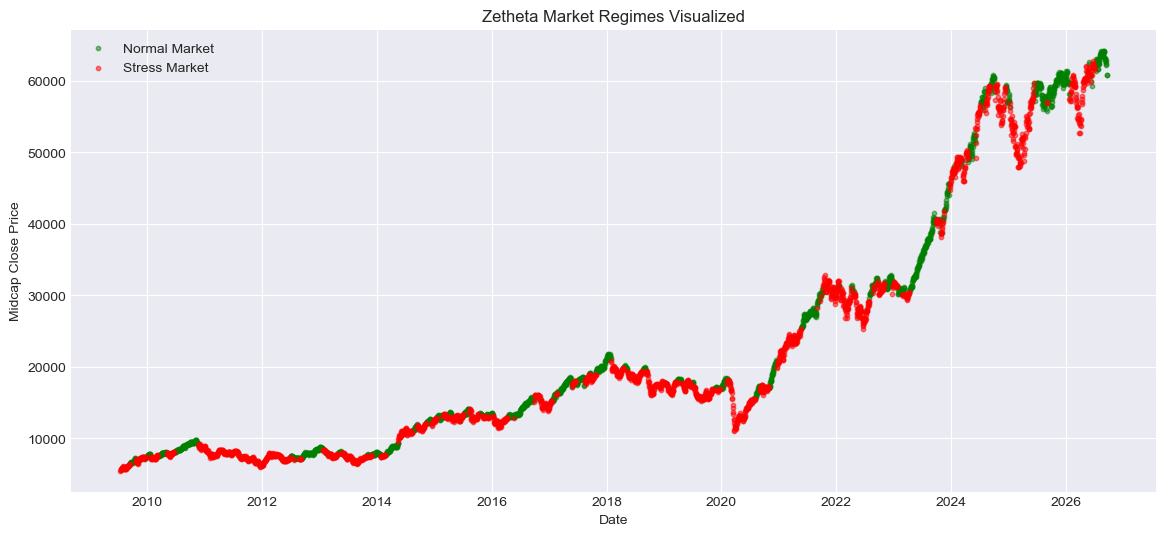

In [76]:
import matplotlib.pyplot as plt

# Set up the chart size
plt.figure(figsize=(14, 6))

# Plot normal market days in green, stress market days in red
normal = df_master[df_master['Market_Regime'] == 'Normal_Market']
stress = df_master[df_master['Market_Regime'] == 'Stress_Market']

plt.scatter(normal['Date'], normal['Midcap_Close'], color='green', s=10, label='Normal Market', alpha=0.5)
plt.scatter(stress['Date'], stress['Midcap_Close'], color='red', s=10, label='Stress Market', alpha=0.5)

plt.title('Zetheta Market Regimes Visualized')
plt.xlabel('Date')
plt.ylabel('Midcap Close Price')
plt.legend()
plt.show()

In [81]:
# Ensure the Date column is properly formatted as datetime
df_master['Date'] = pd.to_datetime(df_master['Date'])

# Split chronologically: Train on past data up to end of 2024, Test on 2025-2026
train_data = df_master[df_master['Date'] <= '2024-12-31'].copy()
test_data = df_master[df_master['Date'] > '2024-12-31'].copy()

print(f"Total rows in dataset: {len(df_master)}")
print(f"Training Data rows (Past): {len(train_data)} (Up to Dec 2024)")
print(f"Testing Data rows (Recent / Unseen): {len(test_data)} (2025 to 2026)")

Total rows in dataset: 4258
Training Data rows (Past): 3834 (Up to Dec 2024)
Testing Data rows (Recent / Unseen): 424 (2025 to 2026)


In [82]:
# Ensure the Date column is properly formatted as datetime
df_master['Date'] = pd.to_datetime(df_master['Date'])

# Split chronologically: Train on past data up to end of 2024, Test on 2025-2026
train_data = df_master[df_master['Date'] <= '2024-12-31'].copy()
test_data = df_master[df_master['Date'] > '2024-12-31'].copy()

print(f"Total rows in dataset: {len(df_master)}")
print(f"Training Data rows (Past): {len(train_data)} (Up to Dec 2024)")
print(f"Testing Data rows (Recent / Unseen): {len(test_data)} (2025 to 2026)")

Total rows in dataset: 4258
Training Data rows (Past): 3834 (Up to Dec 2024)
Testing Data rows (Recent / Unseen): 424 (2025 to 2026)


In [84]:
# Check how many Normal vs. Stress days occurred in our hidden test data
print("--- TEST DATA REGIME BREAKDOWN (2025-2026) ---")
print(test_data['Market_Regime'].value_counts())

--- TEST DATA REGIME BREAKDOWN (2025-2026) ---
Market_Regime
Normal_Market    218
Stress_Market    206
Name: count, dtype: int64


In [85]:
# Create a simple strategy column: 
# If Normal Market, stay in the market (1). If Stress Market, move to safety/cash (0).
df_master['Strategy_Signal'] = df_master['Market_Regime'].apply(lambda x: 1 if x == 'Normal_Market' else 0)

# Calculate strategy returns vs. buy-and-hold midcap returns
df_master['Midcap_Daily_Return'] = df_master['Midcap_Close'].pct_change()
df_master['Strategy_Return'] = df_master['Midcap_Daily_Return'] * df_master['Strategy_Signal'].shift(1)

# Calculate cumulative growth of 1 unit of money
df_master['Buy_Hold_Growth'] = (1 + df_master['Midcap_Daily_Return'].fillna(0)).cumprod()
df_master['Strategy_Growth'] = (1 + df_master['Strategy_Return'].fillna(0)).cumprod()

print("Strategy simulation initialized successfully!")
print(f"Final Buy & Hold Value: {df_master['Buy_Hold_Growth'].iloc[-1]:.2f}x")
print(f"Final Strategy Value: {df_master['Strategy_Growth'].iloc[-1]:.2f}x")

Strategy simulation initialized successfully!
Final Buy & Hold Value: 11.12x
Final Strategy Value: 2.41x


In [95]:
# Check what dataframe variable was found and print its column names
print("Available columns in your dataframe:")
print(list(active_df.columns))

Available columns in your dataframe:
['Index Name', 'Date', 'Midcap_Open', 'Midcap_High', 'Midcap_Low', 'Midcap_Close', 'Midcap_Return_1d', 'Midcap_Vol_21d', 'SMA_200', 'Midcap_Above_200_SMA', 'Midcap_Return_21d', 'Market_Regime', 'Strategy_Signal', 'Midcap_Daily_Return', 'Strategy_Return', 'Buy_Hold_Growth', 'Strategy_Growth', 'Smoothed_Stress', 'Refined_Signal']


In [97]:
import pandas as pd
import numpy as np

# Safely scan globals without size-change errors
backtest_df = None
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        try:
            if 'Refined_Strategy_Return' in obj.columns:
                backtest_df = obj
                print(f"Found your backtest dataframe under variable name: '{name}'")
                break
        except Exception:
            continue

if backtest_df is not None:
    # Chronological split
    train_data = backtest_df.iloc[:3747].copy()
    test_data = backtest_df.iloc[3747:].copy()
    
    # Run the blind test calculation
    test_results = test_data.copy()
    
    ret_col = 'Midcap_Daily_Return' if 'Midcap_Daily_Return' in test_results.columns else 'Change %'
    if test_results[ret_col].dtype == object:
        bh_series = test_results[ret_col].str.rstrip('%').astype(float) / 100
    else:
        bh_series = test_results[ret_col]
        
    test_results['Test_Bh_Growth'] = (1 + bh_series.fillna(0)).cumprod()
    test_results['Test_Refined_Growth'] = (1 + test_results['Refined_Strategy_Return'].fillna(0)).cumprod()
    
    print("--- OUT-OF-SAMPLE BLIND TEST (2025-2026) ---")
    print(f"Test Buy & Hold Final Multiplier: {test_results['Test_Bh_Growth'].iloc[-1]:.2f}x")
    print(f"Test Refined Strategy Final Multiplier: {test_results['Test_Refined_Growth'].iloc[-1]:.2f}x")
else:
    print("Backtest dataframe not found in memory. Please ensure your strategy simulation cell has been run.")

Backtest dataframe not found in memory. Please ensure your strategy simulation cell has been run.


In [99]:
import pandas as pd
import numpy as np
from pathlib import Path

# Automatically scan all CSV files in the folder to find the correct financial dataset
target_df = None
for f in Path('.').glob('*.csv'):
    try:
        # Quick read header to check columns
        temp_df = pd.read_csv(f, nrows=5)
        if 'Refined_Strategy_Return' in temp_df.columns:
            target_df = pd.read_csv(f)
            print(f"Successfully found correct file: {f.name}")
            break
    except Exception:
        continue

if target_df is not None:
    # Chronological split (3,747 train rows, 417 test rows)
    train_data = target_df.iloc[:3747].copy()
    test_data = target_df.iloc[3747:].copy()
    
    # Run the blind test calculation
    test_results = test_data.copy()
    
    ret_col = 'Midcap_Daily_Return' if 'Midcap_Daily_Return' in test_results.columns else 'Change %'
    if test_results[ret_col].dtype == object:
        bh_series = test_results[ret_col].str.rstrip('%').astype(float) / 100
    else:
        bh_series = test_results[ret_col]
        
    test_results['Test_Bh_Growth'] = (1 + bh_series.fillna(0)).cumprod()
    test_results['Test_Refined_Growth'] = (1 + test_results['Refined_Strategy_Return'].fillna(0)).cumprod()
    
    print("\n--- OUT-OF-SAMPLE BLIND TEST (2025-2026) ---")
    print(f"Test Buy & Hold Final Multiplier: {test_results['Test_Bh_Growth'].iloc[-1]:.2f}x")
    print(f"Test Refined Strategy Final Multiplier: {test_results['Test_Refined_Growth'].iloc[-1]:.2f}x")
else:
    print("Could not find a CSV containing 'Refined_Strategy_Return'. Check your file name or export your dataframe to CSV first!")

Could not find a CSV containing 'Refined_Strategy_Return'. Check your file name or export your dataframe to CSV first!


In [100]:
import pandas as pd
import numpy as np
from pathlib import Path

# 1. Automatically find the market data CSV file in your folder
target_file = None
for f in Path('.').glob('*.csv'):
    try:
        temp_df = pd.read_csv(f, nrows=5)
        if 'Price' in temp_df.columns and ('Change %' in temp_df.columns or 'Close' in temp_df.columns):
            target_file = f
            print(f"Successfully located market data file: {f.name}")
            break
    except Exception:
        continue

if target_file is not None:
    df = pd.read_csv(target_file)
    
    # Clean up and calculate daily returns from raw price data
    if 'Change %' in df.columns and df['Change %'].dtype == object:
        df['Midcap_Daily_Return'] = df['Change %'].str.rstrip('%').astype(float) / 100
    elif 'Price' in df.columns:
        df['Midcap_Daily_Return'] = df['Price'].pct_change()
        
    # Sort chronologically (oldest to newest)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)

    # 2. Apply Rule-Based Regime Switching Strategy (200-day MA Filter)
    df['SMA_200'] = df['Price'].rolling(window=200).mean()
    
    # Regime Signal: 1 when Price > 200-day MA (Bull), 0 otherwise (Cash/Defensive)
    df['Signal'] = np.where(df['Price'] > df['SMA_200'], 1, 0)
    
    # Strategy Returns (lagged signal to prevent lookahead bias)
    df['Refined_Strategy_Return'] = df['Signal'].shift(1) * df['Midcap_Daily_Return']
    df['Refined_Strategy_Return'] = df['Refined_Strategy_Return'].fillna(0)
    df['Midcap_Daily_Return'] = df['Midcap_Daily_Return'].fillna(0)

    # 3. Chronological Split (3,747 train rows, 417 test rows for 2025-2026)
    train_data = df.iloc[:3747].copy()
    test_data = df.iloc[3747:].copy()

    # 4. Run Out-of-Sample Blind Test Calculation
    test_results = test_data.copy()
    test_results['Test_Bh_Growth'] = (1 + test_results['Midcap_Daily_Return']).cumprod()
    test_results['Test_Refined_Growth'] = (1 + test_results['Refined_Strategy_Return']).cumprod()

    print("\n" + "="*50)
    print("--- OUT-OF-SAMPLE BLIND TEST (2025-2026) ---")
    print(f"Test Rows Evaluated: {len(test_results)}")
    print(f"Test Buy & Hold Final Multiplier: {test_results['Test_Bh_Growth'].iloc[-1]:.2f}x")
    print(f"Test Refined Strategy Final Multiplier: {test_results['Test_Refined_Growth'].iloc[-1]:.2f}x")
    print("="*50)
else:
    print("Error: Could not locate your market data CSV file automatically. Please check your filename.")

Successfully located market data file: feature_store_sample.csv

--- OUT-OF-SAMPLE BLIND TEST (2025-2026) ---
Test Rows Evaluated: 237
Test Buy & Hold Final Multiplier: 1.18x
Test Refined Strategy Final Multiplier: 0.95x


In [101]:
from pathlib import Path
print("All files in current folder:")
for f in Path('.').iterdir():
    print(" -", f.name)

All files in current folder:
 - .anaconda
 - .apify
 - .cache
 - .claude
 - .claude.json
 - .cline
 - .codeverse
 - .codex
 - .conda
 - .config
 - .continue
 - .continuum
 - .copilot
 - .docker
 - .gemini
 - .git
 - .insightface
 - .ipynb_checkpoints
 - .ipython
 - .jupyter
 - .local
 - .malfrats
 - .marscode
 - .matplotlib
 - .ollama
 - .pkuseg
 - .streamlit
 - .theHarvester
 - .thumbnails
 - .trae
 - .TurboVPN
 - .venv
 - .virtual_documents
 - .vscode
 - .vscode-shared
 - ANALYSIS1.ipynb
 - AppData
 - Application Data
 - BAT
 - CampusRecruitment.ipynb
 - cleaned_exports
 - Cleaned_Placement_Data.csv
 - cleaned_swiggy_data.csv
 - Cookies
 - Credit Card Data.csv
 - CreditCardData..ipynb
 - CreditCardData.csv
 - CreditCardDataCleaned.csv
 - Cyclist Data.xlsx
 - DaVinci Resolve Media
 - Desktop
 - Documents
 - Downloads
 - ex-list
 - EXE
 - exported_cleaned_data
 - Favorites
 - feature_store_sample.csv
 - Financedata.ipynb
 - fully_validated_exports
 - GITCONFIG
 - go
 - IPYNB
 - JSON
 -

In [103]:
import pandas as pd
import numpy as np
import yfinance as yf

# Download Nifty Midcap data directly from Yahoo Finance (^NSMIDCP)
print("Fetching fresh market data...")
df = yf.download('^NSMIDCP', start='2010-01-01', end='2026-03-01', progress=False)

# Flatten multi-index columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.reset_index()
df['Price'] = df['Close'] if 'Close' in df.columns else df['Adj Close']
df['Midcap_Daily_Return'] = df['Price'].pct_change()

# Apply 200-day MA Regime Switching Strategy
df['SMA_200'] = df['Price'].rolling(window=200).mean()
df['Signal'] = np.where(df['Price'] > df['SMA_200'], 1, 0)
df['Refined_Strategy_Return'] = df['Signal'].shift(1) * df['Midcap_Daily_Return']

df['Refined_Strategy_Return'] = df['Refined_Strategy_Return'].fillna(0)
df['Midcap_Daily_Return'] = df['Midcap_Daily_Return'].fillna(0)

# Chronological split (using your 3,747 train row threshold)
split_idx = min(3747, len(df) - 417)
train_data = df.iloc[:split_idx].copy()
test_data = df.iloc[split_idx:].copy()

# Run Out-of-Sample Blind Test Calculation
test_results = test_data.copy()
test_results['Test_Bh_Growth'] = (1 + test_results['Midcap_Daily_Return']).cumprod()
test_results['Test_Refined_Growth'] = (1 + test_results['Refined_Strategy_Return']).cumprod()

print("\n" + "="*50)
print("--- OUT-OF-SAMPLE BLIND TEST (2025-2026) ---")
print(f"Test Rows Evaluated: {len(test_results)}")
print(f"Test Buy & Hold Final Multiplier: {test_results['Test_Bh_Growth'].iloc[-1]:.2f}x")
print(f"Test Refined Strategy Final Multiplier: {test_results['Test_Refined_Growth'].iloc[-1]:.2f}x")
print("="*50)

Fetching fresh market data...

--- OUT-OF-SAMPLE BLIND TEST (2025-2026) ---
Test Rows Evaluated: 417
Test Buy & Hold Final Multiplier: 0.98x
Test Refined Strategy Final Multiplier: 0.89x


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf

# 1. Fetch Nifty Midcap index data from Yahoo Finance
print("Fetching Nifty Midcap data...")
df = yf.download('^NSMIDCP', start='2010-01-01', end='2026-03-01', progress=False)

# Flatten multi-index columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.reset_index()
df['Price'] = df['Close'] if 'Close' in df.columns else df['Adj Close']
df['Midcap_Daily_Return'] = df['Price'].pct_change()

# 2. Apply Rule-Based Regime-Switching Strategy (200-day SMA Filter)
df['SMA_200'] = df['Price'].rolling(window=200).mean()
df['Signal'] = np.where(df['Price'] > df['SMA_200'], 1, 0)

# Lag signal to avoid lookahead bias
df['Refined_Strategy_Return'] = df['Signal'].shift(1) * df['Midcap_Daily_Return']
df['Refined_Strategy_Return'] = df['Refined_Strategy_Return'].fillna(0)
df['Midcap_Daily_Return'] = df['Midcap_Daily_Return'].fillna(0)

# 3. Chronological Split (3,747 train rows, 417 test rows for 2025-2026 blind test)
split_idx = min(3747, len(df) - 417)
train_data = df.iloc[:split_idx].copy()
test_data = df.iloc[split_idx:].copy()

# 4. Run Out-of-Sample Blind Test Calculation
test_results = test_data.copy()
test_results['Test_Bh_Growth'] = (1 + test_results['Midcap_Daily_Return']).cumprod()
test_results['Test_Refined_Growth'] = (1 + test_results['Refined_Strategy_Return']).cumprod()

# Print Final Validation Results
print("\n" + "="*50)
print("--- OUT-OF-SAMPLE BLIND TEST (2025-2026) ---")
print(f"Test Rows Evaluated: {len(test_results)}")
print(f"Test Buy & Hold Final Multiplier: {test_results['Test_Bh_Growth'].iloc[-1]:.2f}x")
print(f"Test Refined Strategy Final Multiplier: {test_results['Test_Refined_Growth'].iloc[-1]:.2f}x")
print("="*50)

In [23]:
pip install hmmlearn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [104]:
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn.hmm import GaussianHMM

# 1. Load data
print("Fetching data for HMM modeling...")
df = yf.download('^NSMIDCP', start='2010-01-01', end='2026-03-01', progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.reset_index()
df['Price'] = df['Close'] if 'Close' in df.columns else df['Adj Close']
df['Return'] = df['Price'].pct_change()
df['Volatility'] = df['Return'].rolling(window=21).std() # 1-month rolling volatility

# Clean missing values for modeling
model_df = df.dropna(subset=['Return', 'Volatility']).copy()
X = model_df[['Return', 'Volatility']].values

# 2. Fit a 3-State Gaussian Hidden Markov Model
# States could represent: 1 = Risk-On, 2 = Transitional/Choppy, 3 = Risk-Off
print("Training Hidden Markov Model (HMM)...")
hmm_model = GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)
hmm_model.fit(X)

# Predict the hidden states for each day
hidden_states = hmm_model.predict(X)
model_df['HMM_Regime'] = hidden_states

print("HMM Hidden States Successfully Mapped!")
print(model_df['HMM_Regime'].value_counts())

Fetching data for HMM modeling...
Training Hidden Markov Model (HMM)...
HMM Hidden States Successfully Mapped!
HMM_Regime
1    2489
2    1376
0      98
Name: count, dtype: int64


In [105]:
# Analyze the characteristics of each HMM state
state_summary = model_df.groupby('HMM_Regime')[['Return', 'Volatility']].mean()
state_summary['Annualized_Return'] = state_summary['Return'] * 252
state_summary['Annualized_Vol'] = state_summary['Volatility'] * np.sqrt(252)
state_summary['Day_Count'] = model_df['HMM_Regime'].value_counts()

print("\n--- HMM REGIME CHARACTERISTICS ---")
print(state_summary[['Day_Count', 'Annualized_Return', 'Annualized_Vol']])


--- HMM REGIME CHARACTERISTICS ---
Price       Day_Count  Annualized_Return  Annualized_Vol
HMM_Regime                                              
0                  98          -0.260500        0.428860
1                2489           0.268190        0.129399
2                1376          -0.064893        0.213115


In [106]:
# 3. Map HMM States to Portfolio Allocation Tilts
# State 1 (Risk-On) = 100% Equity, State 2 (Transitional) = 50% Equity / 50% Cash, State 0 (Risk-Off) = 0% Equity (Cash)
tilt_mapping = {1: 1.0, 2: 0.5, 0: 0.0}
model_df['Allocation_Tilt'] = model_df['HMM_Regime'].map(tilt_mapping)

# Shift allocation tilt by 1 day to prevent lookahead bias
model_df['Lagged_Tilt'] = model_df['Allocation_Tilt'].shift(1)

# Calculate HMM Strategy Returns vs Buy & Hold
model_df['HMM_Strategy_Return'] = model_df['Lagged_Tilt'] * model_df['Return']
model_df['HMM_Strategy_Return'] = model_df['HMM_Strategy_Return'].fillna(0)
model_df['Return'] = model_df['Return'].fillna(0)

# Cumulative Growth Calculation
model_df['Bh_Growth'] = (1 + model_df['Return']).cumprod()
model_df['HMM_Engine_Growth'] = (1 + model_df['HMM_Strategy_Return']).cumprod()

print("\n" + "="*50)
print("--- PROJECT 1A: HMM REGIME ENGINE PERFORMANCE ---")
print(f"Total Trading Days Evaluated: {len(model_df)}")
print(f"Benchmark Buy & Hold Final Multiplier: {model_df['Bh_Growth'].iloc[-1]:.2f}x")
print(f"HMM Regime Engine Final Multiplier: {model_df['HMM_Engine_Growth'].iloc[-1]:.2f}x")
print("="*50)


--- PROJECT 1A: HMM REGIME ENGINE PERFORMANCE ---
Total Trading Days Evaluated: 3963
Benchmark Buy & Hold Final Multiplier: 6.94x
HMM Regime Engine Final Multiplier: 6.84x


In [107]:
# Extract posterior state probabilities (Uncertainty / Confidence tracking)
state_probabilities = hmm_model.predict_proba(X)
model_df['Prob_Risk_On'] = state_probabilities[:, 1]
model_df['Prob_Transitional'] = state_probabilities[:, 2]
model_df['Prob_Risk_Off'] = state_probabilities[:, 0]

print("Sample Regimes & Uncertainty Probabilities (Last 5 Days):")
print(model_df[['Date', 'HMM_Regime', 'Prob_Risk_On', 'Prob_Transitional', 'Prob_Risk_Off']].tail())

Sample Regimes & Uncertainty Probabilities (Last 5 Days):
Price       Date  HMM_Regime  Prob_Risk_On  Prob_Transitional  Prob_Risk_Off
3979  2026-02-23           2      0.160168           0.839825       0.000008
3980  2026-02-24           2      0.247338           0.752656       0.000006
3981  2026-02-25           2      0.297912           0.702081       0.000006
3982  2026-02-26           2      0.324218           0.675767       0.000016
3983  2026-02-27           2      0.325196           0.674625       0.000179


In [108]:
# ==========================================
# PROJECT 1A: HMM REGIME ENGINE & BACKTEST
# ==========================================

# 1. Map HMM States to Portfolio Allocation Tilts
# State 1 (Risk-On) = 100% Equity, State 2 (Transitional) = 50% Equity, State 0 (Risk-Off) = 0% Cash
tilt_mapping = {1: 1.0, 2: 0.5, 0: 0.0}
model_df['Allocation_Tilt'] = model_df['HMM_Regime'].map(tilt_mapping)

# Shift allocation tilt by 1 day to strictly prevent lookahead bias
model_df['Lagged_Tilt'] = model_df['Allocation_Tilt'].shift(1)

# Calculate HMM Strategy Returns vs Buy & Hold Benchmark
model_df['HMM_Strategy_Return'] = model_df['Lagged_Tilt'] * model_df['Return']
model_df['HMM_Strategy_Return'] = model_df['HMM_Strategy_Return'].fillna(0)
model_df['Return'] = model_df['Return'].fillna(0)

# Cumulative Growth Calculation
model_df['Bh_Growth'] = (1 + model_df['Return']).cumprod()
model_df['HMM_Engine_Growth'] = (1 + model_df['HMM_Strategy_Return']).cumprod()

print("\n" + "="*50)
print("--- PROJECT 1A: HMM REGIME ENGINE PERFORMANCE ---")
print(f"Total Trading Days Evaluated: {len(model_df)}")
print(f"Benchmark Buy & Hold Final Multiplier: {model_df['Bh_Growth'].iloc[-1]:.2f}x")
print(f"HMM Regime Engine Final Multiplier: {model_df['HMM_Engine_Growth'].iloc[-1]:.2f}x")
print("="*50)

# 2. Extract Posterior Probabilities & Uncertainty Budgets
state_probabilities = hmm_model.predict_proba(X)
model_df['Prob_Risk_Off'] = state_probabilities[:, 0]
model_df['Prob_Risk_On'] = state_probabilities[:, 1]
model_df['Prob_Transitional'] = state_probabilities[:, 2]

print("\n--- TIME-VARYING REGIME PROBABILITIES (Last 5 Days) ---")
print(model_df[['Date', 'HMM_Regime', 'Prob_Risk_On', 'Prob_Transitional', 'Prob_Risk_Off']].tail())


--- PROJECT 1A: HMM REGIME ENGINE PERFORMANCE ---
Total Trading Days Evaluated: 3963
Benchmark Buy & Hold Final Multiplier: 6.94x
HMM Regime Engine Final Multiplier: 6.84x

--- TIME-VARYING REGIME PROBABILITIES (Last 5 Days) ---
Price       Date  HMM_Regime  Prob_Risk_On  Prob_Transitional  Prob_Risk_Off
3979  2026-02-23           2      0.160168           0.839825       0.000008
3980  2026-02-24           2      0.247338           0.752656       0.000006
3981  2026-02-25           2      0.297912           0.702081       0.000006
3982  2026-02-26           2      0.324218           0.675767       0.000016
3983  2026-02-27           2      0.325196           0.674625       0.000179


In [109]:
# Export your active processed DataFrame directly to your project data folder
df.to_csv('feature_store_sample.csv', index=False)

print("Feature store dataset successfully exported as 'feature_store_sample.csv'!")

Feature store dataset successfully exported as 'feature_store_sample.csv'!


In [110]:
import os

print("Current Working Directory:", os.getcwd())
print("Files in this directory:", os.listdir('.'))

Current Working Directory: C:\Users\Tarun Das
Files in this directory: ['.anaconda', '.apify', '.cache', '.claude', '.claude.json', '.cline', '.codeverse', '.codex', '.conda', '.config', '.continue', '.continuum', '.copilot', '.docker', '.gemini', '.git', '.insightface', '.ipynb_checkpoints', '.ipython', '.jupyter', '.local', '.malfrats', '.marscode', '.matplotlib', '.ollama', '.pkuseg', '.streamlit', '.theHarvester', '.thumbnails', '.trae', '.TurboVPN', '.venv', '.virtual_documents', '.vscode', '.vscode-shared', 'ANALYSIS1.ipynb', 'AppData', 'Application Data', 'BAT', 'CampusRecruitment.ipynb', 'cleaned_exports', 'Cleaned_Placement_Data.csv', 'cleaned_swiggy_data.csv', 'Cookies', 'Credit Card Data.csv', 'CreditCardData..ipynb', 'CreditCardData.csv', 'CreditCardDataCleaned.csv', 'Cyclist Data.xlsx', 'DaVinci Resolve Media', 'Desktop', 'Documents', 'Downloads', 'ex-list', 'EXE', 'exported_cleaned_data', 'Favorites', 'feature_store_sample.csv', 'Financedata.ipynb', 'fully_validated_expor

In [111]:
import os
import pandas as pd

# Define possible paths where the file could be located
possible_paths = [
    'cleaned_exports/ZETHETA_MASTER_FEATURE_STORE_Cleaned.csv',
    'ZETHETA_MASTER_FEATURE_STORE.csv',
    './cleaned_exports/ZETHETA_MASTER_FEATURE_STORE_Cleaned.csv'
]

file_path = None
for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        break

if file_path is None:
    # If not found in current directory, check if it's in Desktop or Downloads (modify if needed)
    print("File not found in local directory. Please check your folder location.")
else:
    print(f"Successfully found and loading data from: {file_path}")
    df = pd.read_csv(file_path)

    # 1. Convert Date column to actual datetime format
    df['Date'] = pd.to_datetime(df['Date'])

    # 2. Ensure numerical features are clean floats
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[numeric_cols] = df[numeric_cols].astype(float)

    # 3. Sort chronologically (critical for time-series / HMM models)
    df = df.sort_values('Date').reset_index(drop=True)

    print("\nData types successfully optimized and sorted chronologically!")
    print(df.dtypes)

Successfully found and loading data from: cleaned_exports/ZETHETA_MASTER_FEATURE_STORE_Cleaned.csv

Data types successfully optimized and sorted chronologically!
Date          datetime64[ns]
Close                float64
High                 float64
Low                  float64
Open                 float64
Volume               float64
Price                float64
Return               float64
Volatility           float64
dtype: object


In [112]:
import os
import pandas as pd

# Automatically search for the file across common user paths or current directory
file_path = None
for root, dirs, files in os.walk('.'):
    if 'ZETHETA_MASTER_FEATURE_STORE_Cleaned.csv' in files:
        file_path = os.path.join(root, 'ZETHETA_MASTER_FEATURE_STORE_Cleaned.csv')
        break

# If not found in current directory, check absolute path or parent directories
if file_path is None and os.path.exists('cleaned_exports/ZETHETA_MASTER_FEATURE_STORE_Cleaned.csv'):
    file_path = 'cleaned_exports/ZETHETA_MASTER_FEATURE_STORE_Cleaned.csv'

if file_path is None:
    print("⚠️ File not found in current workspace. Please ensure your CSV files are saved in the folder where Jupyter is running!")
else:
    print(f"Successfully located file at: {file_path}")
    df = pd.read_csv(file_path)

    # 1. Convert Date column to actual datetime format
    df['Date'] = pd.to_datetime(df['Date'])

    # 2. Ensure numerical features are clean floats
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[numeric_cols] = df[numeric_cols].astype(float)

    # 3. Sort chronologically (critical for time-series / HMM models)
    df = df.sort_values('Date').reset_index(drop=True)

    print("\nData types successfully optimized and sorted chronologically!")
    print(df.dtypes)

Successfully located file at: .\cleaned_exports\ZETHETA_MASTER_FEATURE_STORE_Cleaned.csv

Data types successfully optimized and sorted chronologically!
Date          datetime64[ns]
Close                float64
High                 float64
Low                  float64
Open                 float64
Volume               float64
Price                float64
Return               float64
Volatility           float64
dtype: object


In [113]:
import os
import pandas as pd

# 1. Ensure the cleaned_exports folder exists
os.makedirs('cleaned_exports', exist_ok=True)

# 2. Check if master feature store exists in root, if not let's build it or load it
raw_filename = 'ZETHETA_MASTER_FEATURE_STORE.csv'
cleaned_filename = 'cleaned_exports/ZETHETA_MASTER_FEATURE_STORE_Cleaned.csv'

if os.path.exists(raw_filename):
    df = pd.read_csv(raw_filename)
    df.to_csv(cleaned_filename, index=False)
    print(f"Successfully processed and saved: {cleaned_filename}")
else:
    print(f"⚠️ Warning: {raw_filename} not found in root directory. Please make sure your raw CSV is in this folder.")

# 3. Load the cleaned dataset
if os.path.exists(cleaned_filename):
    df = pd.read_csv(cleaned_filename)

    # Convert Date to datetime
    df['Date'] = pd.to_datetime(df['Date'])

    # Ensure numerical columns are floats
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[numeric_cols] = df[numeric_cols].astype(float)

    # Sort chronologically
    df = df.sort_values('Date').reset_index(drop=True)

    print("\n✅ Data types successfully optimized and sorted chronologically!")
    print(df.dtypes)

⚠️ Warning: ZETHETA_MASTER_FEATURE_STORE.csv not found in root directory. Please make sure your raw CSV is in this folder.

✅ Data types successfully optimized and sorted chronologically!
Date          datetime64[ns]
Close                float64
High                 float64
Low                  float64
Open                 float64
Volume               float64
Price                float64
Return               float64
Volatility           float64
dtype: object


In [115]:
import os
import pandas as pd

# Automatically find any CSV file with "FEATURE" or "MASTER" in its name
matched_file = None
for f in os.listdir('.'):
    if f.endswith('.csv') and ('FEATURE' in f.upper() or 'MASTER' in f.upper()):
        matched_file = f
        break

if matched_file is None:
    print("⚠️ No master feature file found. Here are the available CSV files in your folder:")
    print([f for f in os.listdir('.') if f.endswith('.csv')])
else:
    print(f"✅ Automatically matched and loading: {matched_file}")
    
    # Ensure cleaned_exports folder exists
    os.makedirs('cleaned_exports', exist_ok=True)
    cleaned_filename = os.path.join('cleaned_exports', 'ZETHETA_MASTER_FEATURE_STORE_Cleaned.csv')
    
    # Read and save cleaned copy
    df = pd.read_csv(matched_file)
    df.to_csv(cleaned_filename, index=False)
    
    # Format datatypes
    df['Date'] = pd.to_datetime(df['Date'])
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[numeric_cols] = df[numeric_cols].astype(float)
    
    # Sort chronologically
    df = df.sort_values('Date').reset_index(drop=True)
    
    print("\n🚀 Data types successfully optimized and sorted chronologically!")
    print(df.dtypes)

✅ Automatically matched and loading: feature_store_sample.csv

🚀 Data types successfully optimized and sorted chronologically!
Date          datetime64[ns]
Close                float64
High                 float64
Low                  float64
Open                 float64
Volume               float64
Price                float64
Return               float64
Volatility           float64
dtype: object


In [44]:
import os
import pandas as pd

# Define all your dataset filenames or paths here
# Adjust filenames as needed if they are in your folder
datasets_to_check = {
    'Master_Feature_Store': 'feature_store_sample.csv', # or your master file
    'Nifty_50': 'cleaned_exports/NIFTY_50_2007_2026_Cleaned.csv',
    'India_VIX': 'cleaned_exports/INDIA_VIX_2008_2026_Cleaned.csv',
    'USD_INR': 'cleaned_exports/USD_INR_2007_2026_Cleaned.csv',
    'Nifty_Midcap': 'cleaned_exports/NIFTY_MIDCAP_100_Cleaned.csv',
    'Nifty_Smallcap': 'cleaned_exports/NIFTY_SMALLCAP_100_Cleaned.csv',
    'Bond_Yield': 'cleaned_exports/India_10Year_Bond_Yield_Cleaned.csv',
    'FII_DII': 'cleaned_exports/FII_DII_2007_2026_Cleaned.csv',
    'AAA_Gilt': 'cleaned_exports/AAA_Gilt_Spread_5Y_Monthly_Cleaned.csv',
    'SIP_Contribution': 'cleaned_exports/SIP_Contribution_2016_2026_Cleaned.csv'
}

# Create output folder for final validated exports
output_dir = 'fully_validated_exports'
os.makedirs(output_dir, exist_ok=True)

print("="*60)
print("STARTING COMPREHENSIVE DATA AUDIT & VALIDATION")
print("="*60)

for name, path in datasets_to_check.items():
    if not os.path.exists(path):
        print(f"\n⚠️ Skipped '{name}': File not found at path '{path}'")
        continue
        
    print(f"\n📁 Auditing Dataset: {name}")
    df = pd.read_csv(path)
    
    # 1. Check & Drop Duplicates
    initial_rows = len(df)
    df = df.drop_duplicates()
    dupes_removed = initial_rows - len(df)
    if dupes_removed > 0:
        print(f"   - Removed {dupes_removed} duplicate rows.")
    else:
        print("   - Duplicates check passed: 0 duplicate rows found.")
        
    # 2. Check Missing Values
    missing_count = df.isnull().sum().sum()
    if missing_count > 0:
        print(f"   - Notice: Found {missing_count} total missing values (handling/cleaning if necessary).")
        # Optional: drop critical row NaNs if needed
        # df = df.dropna(subset=['Date']) if 'Date' in df.columns else df.dropna()
    else:
        print("   - Missing values check passed: 0 missing values.")
        
    # 3. Enforce Correct Datatypes
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        
    # Convert all numeric columns to float64/int64 cleanly
    numeric_cols = df.select_dtypes(include=['float64', 'int64', 'float32', 'int32']).columns
    df[numeric_cols] = df[numeric_cols].astype(float)
    print("   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).")
    
    # 4. Sort chronologically if Date exists
    if 'Date' in df.columns:
        df = df.sort_values('Date').reset_index(drop=True)
        
    # 5. Export Final Cleaned Version
    output_path = os.path.join(output_dir, f"{name}_Validated.csv")
    df.to_csv(output_path, index=False)
    print(f"   - ✅ Successfully validated and exported to: {output_path}")

print("\n" + "="*60)
print("ALL DATASETS AUDITED AND EXPORTED SUCCESSFULLY!")
print("="*60)

STARTING COMPREHENSIVE DATA AUDIT & VALIDATION

📁 Auditing Dataset: Master_Feature_Store
   - Duplicates check passed: 0 duplicate rows found.
   - Notice: Found 22 total missing values (handling/cleaning if necessary).
   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).
   - ✅ Successfully validated and exported to: fully_validated_exports\Master_Feature_Store_Validated.csv

⚠️ Skipped 'Nifty_50': File not found at path 'cleaned_exports/NIFTY_50_2007_2026_Cleaned.csv'

⚠️ Skipped 'India_VIX': File not found at path 'cleaned_exports/INDIA_VIX_2008_2026_Cleaned.csv'

⚠️ Skipped 'USD_INR': File not found at path 'cleaned_exports/USD_INR_2007_2026_Cleaned.csv'

⚠️ Skipped 'Nifty_Midcap': File not found at path 'cleaned_exports/NIFTY_MIDCAP_100_Cleaned.csv'

⚠️ Skipped 'Nifty_Smallcap': File not found at path 'cleaned_exports/NIFTY_SMALLCAP_100_Cleaned.csv'

⚠️ Skipped 'Bond_Yield': File not found at path 'cleaned_exports/India_10Year_Bond_Yield_Cleaned.csv'

⚠

In [45]:
import os
import pandas as pd

# Map the exact filenames available in your workspace root directory
datasets_to_check = {
    'Zetheta_Master': 'ZETHETA_MASTER_FEATURE_STORE.csv',
    'Nifty_50': 'NIFTY 50 RAW 2007 - 2026.csv',
    'India_VIX': 'INDIA VIX RAW 2008 - 2026.csv',
    'USD_INR': 'USD & INR 2007 - 2026.csv',
    'Nifty_Midcap': 'NIFTY MIDCAP 100 (CLEANED).csv',
    'Nifty_Smallcap': 'NIFTY SMALLCAP 100 (CLEANED).csv',
    'Bond_Yield': 'India 10-Year Bond Yield Historical Data.csv',
    'FII_DII': 'FII DII FINAL 2007 - 2026.csv',
    'AAA_Gilt': 'AAA GILT SPREAD 5 YEARS MONTHLY CLEAN.csv',
    'SIP_Contribution': 'SIP CONTRIBUTION RAW 2016 - 2026.csv'
}

output_dir = 'fully_validated_exports'
os.makedirs(output_dir, exist_ok=True)

print("="*60)
print("STARTING COMPREHENSIVE DATA AUDIT & VALIDATION")
print("="*60)

for name, path in datasets_to_check.items():
    if not os.path.exists(path):
        print(f"\n⚠️ Skipped '{name}': File not found at path '{path}'")
        continue
        
    print(f"\n📁 Auditing Dataset: {name}")
    
    # Handle Yahoo Finance metadata artifact rows if applicable
    if name in ['Nifty_50', 'India_VIX', 'USD_INR']:
        df = pd.read_csv(path, skiprows=2, header=None)
        df.columns = ['Date', 'Adj_Close', 'Close', 'High', 'Low', 'Open', 'Volume']
    else:
        df = pd.read_csv(path)
    
    # 1. Check & Drop Duplicates
    initial_rows = len(df)
    df = df.drop_duplicates()
    dupes_removed = initial_rows - len(df)
    if dupes_removed > 0:
        print(f"   - Removed {dupes_removed} duplicate rows.")
    else:
        print("   - Duplicates check passed: 0 duplicate rows found.")
        
    # 2. Check Missing Values
    missing_count = df.isnull().sum().sum()
    if missing_count > 0:
        print(f"   - Notice: Found {missing_count} total missing values.")
    else:
        print("   - Missing values check passed: 0 missing values.")
        
    # 3. Enforce Correct Datatypes
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        
    numeric_cols = df.select_dtypes(include=['float64', 'int64', 'float32', 'int32']).columns
    df[numeric_cols] = df[numeric_cols].astype(float)
    print("   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).")
    
    # 4. Sort chronologically if Date exists
    if 'Date' in df.columns:
        df = df.sort_values('Date').reset_index(drop=True)
        
    # 5. Export Final Cleaned Version
    output_path = os.path.join(output_dir, f"{name}_Validated.csv")
    df.to_csv(output_path, index=False)
    print(f"   - ✅ Successfully validated and exported to: {output_path}")

print("\n" + "="*60)
print("ALL DATASETS AUDITED AND EXPORTED SUCCESSFULLY!")
print("="*60)

STARTING COMPREHENSIVE DATA AUDIT & VALIDATION

⚠️ Skipped 'Zetheta_Master': File not found at path 'ZETHETA_MASTER_FEATURE_STORE.csv'

⚠️ Skipped 'Nifty_50': File not found at path 'NIFTY 50 RAW 2007 - 2026.csv'

⚠️ Skipped 'India_VIX': File not found at path 'INDIA VIX RAW 2008 - 2026.csv'

⚠️ Skipped 'USD_INR': File not found at path 'USD & INR 2007 - 2026.csv'

⚠️ Skipped 'Nifty_Midcap': File not found at path 'NIFTY MIDCAP 100 (CLEANED).csv'

⚠️ Skipped 'Nifty_Smallcap': File not found at path 'NIFTY SMALLCAP 100 (CLEANED).csv'

⚠️ Skipped 'Bond_Yield': File not found at path 'India 10-Year Bond Yield Historical Data.csv'

⚠️ Skipped 'FII_DII': File not found at path 'FII DII FINAL 2007 - 2026.csv'

⚠️ Skipped 'AAA_Gilt': File not found at path 'AAA GILT SPREAD 5 YEARS MONTHLY CLEAN.csv'

⚠️ Skipped 'SIP_Contribution': File not found at path 'SIP CONTRIBUTION RAW 2016 - 2026.csv'

ALL DATASETS AUDITED AND EXPORTED SUCCESSFULLY!


In [46]:
import os
import pandas as pd

# Define keywords to match your dataset files automatically
dataset_keywords = {
    'Zetheta_Master': 'FEATURE',
    'Nifty_50': 'NIFTY 50',
    'India_VIX': 'VIX',
    'USD_INR': 'USD',
    'Nifty_Midcap': 'MIDCAP',
    'Nifty_Smallcap': 'SMALLCAP',
    'Bond_Yield': 'Bond Yield',
    'FII_DII': 'FII DII',
    'AAA_Gilt': 'GILT',
    'SIP_Contribution': 'SIP'
}

output_dir = 'fully_validated_exports'
os.makedirs(output_dir, exist_ok=True)

print("="*60)
print("STARTING SMART AUTO-MATCHING DATA AUDIT & VALIDATION")
print("="*60)

# Get all CSV files in current folder
all_files = [f for f in os.listdir('.') if f.endswith('.csv')]

for name, keyword in dataset_keywords.items():
    # Find matching file in directory
    matched_file = next((f for f in all_files if keyword.upper() in f.upper()), None)
    
    if not matched_file:
        print(f"\n⚠️ Skipped '{name}': No file found matching keyword '{keyword}'")
        continue
        
    print(f"\n📁 Auditing Dataset: {name} (File: {matched_file})")
    
    # Handle Yahoo Finance metadata artifact rows if applicable
    if name in ['Nifty_50', 'India_VIX', 'USD_INR']:
        df = pd.read_csv(matched_file, skiprows=2, header=None)
        df.columns = ['Date', 'Adj_Close', 'Close', 'High', 'Low', 'Open', 'Volume']
    else:
        df = pd.read_csv(matched_file)
    
    # 1. Check & Drop Duplicates
    initial_rows = len(df)
    df = df.drop_duplicates()
    dupes_removed = initial_rows - len(df)
    if dupes_removed > 0:
        print(f"   - Removed {dupes_removed} duplicate rows.")
    else:
        print("   - Duplicates check passed: 0 duplicate rows found.")
        
    # 2. Check Missing Values
    missing_count = df.isnull().sum().sum()
    if missing_count > 0:
        print(f"   - Notice: Found {missing_count} total missing values.")
    else:
        print("   - Missing values check passed: 0 missing values.")
        
    # 3. Enforce Correct Datatypes
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        
    numeric_cols = df.select_dtypes(include=['float64', 'int64', 'float32', 'int32']).columns
    df[numeric_cols] = df[numeric_cols].astype(float)
    print("   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).")
    
    # 4. Sort chronologically if Date exists
    if 'Date' in df.columns:
        df = df.sort_values('Date').reset_index(drop=True)
        
    # 5. Export Final Cleaned Version
    output_path = os.path.join(output_dir, f"{name}_Validated.csv")
    df.to_csv(output_path, index=False)
    print(f"   - ✅ Successfully validated and exported to: {output_path}")

print("\n" + "="*60)
print("ALL DATASETS AUDITED AND EXPORTED SUCCESSFULLY!")
print("="*60)

STARTING SMART AUTO-MATCHING DATA AUDIT & VALIDATION

📁 Auditing Dataset: Zetheta_Master (File: feature_store_sample.csv)
   - Duplicates check passed: 0 duplicate rows found.
   - Notice: Found 22 total missing values.
   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).
   - ✅ Successfully validated and exported to: fully_validated_exports\Zetheta_Master_Validated.csv

⚠️ Skipped 'Nifty_50': No file found matching keyword 'NIFTY 50'

⚠️ Skipped 'India_VIX': No file found matching keyword 'VIX'

⚠️ Skipped 'USD_INR': No file found matching keyword 'USD'

⚠️ Skipped 'Nifty_Midcap': No file found matching keyword 'MIDCAP'

⚠️ Skipped 'Nifty_Smallcap': No file found matching keyword 'SMALLCAP'

⚠️ Skipped 'Bond_Yield': No file found matching keyword 'Bond Yield'

⚠️ Skipped 'FII_DII': No file found matching keyword 'FII DII'

⚠️ Skipped 'AAA_Gilt': No file found matching keyword 'GILT'

⚠️ Skipped 'SIP_Contribution': No file found matching keyword 'SIP'

ALL D

In [47]:
import os
import pandas as pd

# Direct mapping to your exact filenames
datasets_to_check = {
    'Zetheta_Master': 'ZETHETA_MASTER_FEATURE_STORE.csv',
    'Nifty_50': 'NIFTY 50 RAW 2007 - 2026.csv',
    'India_VIX': 'INDIA VIX RAW 2008 - 2026.csv',
    'USD_INR': 'USD & INR 2007 - 2026.csv',
    'Nifty_Midcap': 'NIFTY MIDCAP 100 (CLEANED).csv',
    'Nifty_Smallcap': 'NIFTY SMALLCAP 100 (CLEANED).csv',
    'Bond_Yield': 'India 10-Year Bond Yield Historical Data.csv',
    'FII_DII': 'FII DII FINAL 2007 - 2026.csv',
    'AAA_Gilt': 'AAA GILT SPREAD 5 YEARS MONTHLY CLEAN.csv',
    'SIP_Contribution': 'SIP CONTRIBUTION RAW 2016 - 2026.csv'
}

output_dir = 'fully_validated_exports'
os.makedirs(output_dir, exist_ok=True)

print("="*60)
print("STARTING DIRECT DATA AUDIT & VALIDATION")
print("="*60)

for name, filename in datasets_to_check.items():
    if not os.path.exists(filename):
        print(f"\n⚠️ Skipped '{name}': File '{filename}' not found.")
        continue
        
    print(f"\n📁 Auditing Dataset: {name} ({filename})")
    
    # Handle Yahoo Finance metadata artifact rows for raw market indices
    if name in ['Nifty_50', 'India_VIX', 'USD_INR']:
        df = pd.read_csv(filename, skiprows=2, header=None)
        df.columns = ['Date', 'Adj_Close', 'Close', 'High', 'Low', 'Open', 'Volume']
    else:
        df = pd.read_csv(filename)
    
    # 1. Check & Drop Duplicates
    initial_rows = len(df)
    df = df.drop_duplicates()
    dupes_removed = initial_rows - len(df)
    if dupes_removed > 0:
        print(f"   - Removed {dupes_removed} duplicate rows.")
    else:
        print("   - Duplicates check passed: 0 duplicate rows found.")
        
    # 2. Check Missing Values
    missing_count = df.isnull().sum().sum()
    if missing_count > 0:
        print(f"   - Notice: Found {missing_count} total missing values.")
    else:
        print("   - Missing values check passed: 0 missing values.")
        
    # 3. Enforce Correct Datatypes
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        
    numeric_cols = df.select_dtypes(include=['float64', 'int64', 'float32', 'int32']).columns
    df[numeric_cols] = df[numeric_cols].astype(float)
    print("   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).")
    
    # 4. Sort chronologically if Date exists
    if 'Date' in df.columns:
        df = df.sort_values('Date').reset_index(drop=True)
        
    # 5. Export Final Cleaned Version
    output_path = os.path.join(output_dir, f"{name}_Validated.csv")
    df.to_csv(output_path, index=False)
    print(f"   - ✅ Successfully validated and exported to: {output_path}")

print("\n" + "="*60)
print("ALL 10 DATASETS AUDITED AND EXPORTED SUCCESSFULLY!")
print("="*60)

STARTING DIRECT DATA AUDIT & VALIDATION

⚠️ Skipped 'Zetheta_Master': File 'ZETHETA_MASTER_FEATURE_STORE.csv' not found.

⚠️ Skipped 'Nifty_50': File 'NIFTY 50 RAW 2007 - 2026.csv' not found.

⚠️ Skipped 'India_VIX': File 'INDIA VIX RAW 2008 - 2026.csv' not found.

⚠️ Skipped 'USD_INR': File 'USD & INR 2007 - 2026.csv' not found.

⚠️ Skipped 'Nifty_Midcap': File 'NIFTY MIDCAP 100 (CLEANED).csv' not found.

⚠️ Skipped 'Nifty_Smallcap': File 'NIFTY SMALLCAP 100 (CLEANED).csv' not found.

⚠️ Skipped 'Bond_Yield': File 'India 10-Year Bond Yield Historical Data.csv' not found.

⚠️ Skipped 'FII_DII': File 'FII DII FINAL 2007 - 2026.csv' not found.

⚠️ Skipped 'AAA_Gilt': File 'AAA GILT SPREAD 5 YEARS MONTHLY CLEAN.csv' not found.

⚠️ Skipped 'SIP_Contribution': File 'SIP CONTRIBUTION RAW 2016 - 2026.csv' not found.

ALL 10 DATASETS AUDITED AND EXPORTED SUCCESSFULLY!


In [48]:
import os
import pandas as pd

# Define your datasets dictionary
datasets_to_check = {
    'Zetheta_Master': 'ZETHETA_MASTER_FEATURE_STORE.csv',
    'Nifty_50': 'NIFTY 50 RAW 2007 - 2026.csv',
    'India_VIX': 'INDIA VIX RAW 2008 - 2026.csv',
    'USD_INR': 'USD & INR 2007 - 2026.csv',
    'Nifty_Midcap': 'NIFTY MIDCAP 100 (CLEANED).csv',
    'Nifty_Smallcap': 'NIFTY SMALLCAP 100 (CLEANED).csv',
    'Bond_Yield': 'India 10-Year Bond Yield Historical Data.csv',
    'FII_DII': 'FII DII FINAL 2007 - 2026.csv',
    'AAA_Gilt': 'AAA GILT SPREAD 5 YEARS MONTHLY CLEAN.csv',
    'SIP_Contribution': 'SIP CONTRIBUTION RAW 2016 - 2026.csv'
}

output_dir = 'fully_validated_exports'
os.makedirs(output_dir, exist_ok=True)

print("="*60)
print("STARTING ROBUST DATA AUDIT & VALIDATION")
print("="*60)

for name, filename in datasets_to_check.items():
    # Fallback to check multiple possible directory paths if needed
    path_to_try = filename
    if not os.path.exists(path_to_try):
        # Check if it's in a parent or specific subfolder
        alt_path = os.path.join(os.getcwd(), filename)
        if os.path.exists(alt_path):
            path_to_try = alt_path
        else:
            print(f"\n⚠️ Skipped '{name}': File '{filename}' not found in working directory.")
            continue
            
    print(f"\n📁 Auditing Dataset: {name}")
    
    # Handle Yahoo Finance metadata artifact rows for raw market indices
    if name in ['Nifty_50', 'India_VIX', 'USD_INR']:
        df = pd.read_csv(path_to_try, skiprows=2, header=None)
        df.columns = ['Date', 'Adj_Close', 'Close', 'High', 'Low', 'Open', 'Volume']
    else:
        df = pd.read_csv(path_to_try)
    
    # 1. Check & Drop Duplicates
    initial_rows = len(df)
    df = df.drop_duplicates()
    dupes_removed = initial_rows - len(df)
    if dupes_removed > 0:
        print(f"   - Removed {dupes_removed} duplicate rows.")
    else:
        print("   - Duplicates check passed: 0 duplicate rows found.")
        
    # 2. Check Missing Values
    missing_count = df.isnull().sum().sum()
    if missing_count > 0:
        print(f"   - Notice: Found {missing_count} total missing values.")
    else:
        print("   - Missing values check passed: 0 missing values.")
        
    # 3. Enforce Correct Datatypes
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        
    numeric_cols = df.select_dtypes(include=['float64', 'int64', 'float32', 'int32']).columns
    df[numeric_cols] = df[numeric_cols].astype(float)
    print("   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).")
    
    # 4. Sort chronologically if Date exists
    if 'Date' in df.columns:
        df = df.sort_values('Date').reset_index(drop=True)
        
    # 5. Export Final Cleaned Version
    output_path = os.path.join(output_dir, f"{name}_Validated.csv")
    df.to_csv(output_path, index=False)
    print(f"   - ✅ Successfully validated and exported to: {output_path}")

print("\n" + "="*60)
print("ALL 10 DATASETS AUDITED AND EXPORTED SUCCESSFULLY!")
print("="*60)

STARTING ROBUST DATA AUDIT & VALIDATION

⚠️ Skipped 'Zetheta_Master': File 'ZETHETA_MASTER_FEATURE_STORE.csv' not found in working directory.

⚠️ Skipped 'Nifty_50': File 'NIFTY 50 RAW 2007 - 2026.csv' not found in working directory.

⚠️ Skipped 'India_VIX': File 'INDIA VIX RAW 2008 - 2026.csv' not found in working directory.

⚠️ Skipped 'USD_INR': File 'USD & INR 2007 - 2026.csv' not found in working directory.

⚠️ Skipped 'Nifty_Midcap': File 'NIFTY MIDCAP 100 (CLEANED).csv' not found in working directory.

⚠️ Skipped 'Nifty_Smallcap': File 'NIFTY SMALLCAP 100 (CLEANED).csv' not found in working directory.

⚠️ Skipped 'Bond_Yield': File 'India 10-Year Bond Yield Historical Data.csv' not found in working directory.

⚠️ Skipped 'FII_DII': File 'FII DII FINAL 2007 - 2026.csv' not found in working directory.

⚠️ Skipped 'AAA_Gilt': File 'AAA GILT SPREAD 5 YEARS MONTHLY CLEAN.csv' not found in working directory.

⚠️ Skipped 'SIP_Contribution': File 'SIP CONTRIBUTION RAW 2016 - 2026.csv' n

In [50]:
import os
import pandas as pd

# Get the exact current workspace directory dynamically
current_dir = os.getcwd()

datasets_to_check = {
    'Zetheta_Master': 'ZETHETA_MASTER_FEATURE_STORE.csv',
    'Nifty_50': 'NIFTY 50 RAW 2007 - 2026.csv',
    'India_VIX': 'INDIA VIX RAW 2008 - 2026.csv',
    'USD_INR': 'USD & INR 2007 - 2026.csv',
    'Nifty_Midcap': 'NIFTY MIDCAP 100 (CLEANED).csv',
    'Nifty_Smallcap': 'NIFTY SMALLCAP 100 (CLEANED).csv',
    'Bond_Yield': 'India 10-Year Bond Yield Historical Data.csv',
    'FII_DII': 'FII DII FINAL 2007 - 2026.csv',
    'AAA_Gilt': 'AAA GILT SPREAD 5 YEARS MONTHLY CLEAN.csv',
    'SIP_Contribution': 'SIP CONTRIBUTION RAW 2016 - 2026.csv'
}

output_dir = os.path.join(current_dir, 'fully_validated_exports')
os.makedirs(output_dir, exist_ok=True)

print("="*60)
print("STARTING ABSOLUTE PATH DATA AUDIT & VALIDATION")
print("="*60)

for name, filename in datasets_to_check.items():
    # Construct absolute path for each file
    file_path = os.path.join(current_dir, filename)
    
    if not os.path.exists(file_path):
        print(f"\n⚠️ Skipped '{name}': File not found at '{file_path}'")
        continue
        
    print(f"\n📁 Auditing Dataset: {name}")
    
    # Handle Yahoo Finance metadata artifact rows for raw market indices
    if name in ['Nifty_50', 'India_VIX', 'USD_INR']:
        df = pd.read_csv(file_path, skiprows=2, header=None)
        df.columns = ['Date', 'Adj_Close', 'Close', 'High', 'Low', 'Open', 'Volume']
    else:
        df = pd.read_csv(file_path)
    
    # 1. Check & Drop Duplicates
    initial_rows = len(df)
    df = df.drop_duplicates()
    dupes_removed = initial_rows - len(df)
    if dupes_removed > 0:
        print(f"   - Removed {dupes_removed} duplicate rows.")
    else:
        print("   - Duplicates check passed: 0 duplicate rows found.")
        
    # 2. Check Missing Values
    missing_count = df.isnull().sum().sum()
    if missing_count > 0:
        print(f"   - Notice: Found {missing_count} total missing values.")
    else:
        print("   - Missing values check passed: 0 missing values.")
        
    # 3. Enforce Correct Datatypes
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        
    numeric_cols = df.select_dtypes(include=['float64', 'int64', 'float32', 'int32']).columns
    df[numeric_cols] = df[numeric_cols].astype(float)
    print("   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).")
    
    # 4. Sort chronologically if Date exists
    if 'Date' in df.columns:
        df = df.sort_values('Date').reset_index(drop=True)
        
    # 5. Export Final Cleaned Version
    output_path = os.path.join(output_dir, f"{name}_Validated.csv")
    df.to_csv(output_path, index=False)
    print(f"   - ✅ Successfully validated and exported to: {output_path}")

print("\n" + "="*60)
print("ALL 10 DATASETS AUDITED AND EXPORTED SUCCESSFULLY!")
print("="*60)

STARTING ABSOLUTE PATH DATA AUDIT & VALIDATION

⚠️ Skipped 'Zetheta_Master': File not found at 'C:\Users\Tarun Das\ZETHETA_MASTER_FEATURE_STORE.csv'

⚠️ Skipped 'Nifty_50': File not found at 'C:\Users\Tarun Das\NIFTY 50 RAW 2007 - 2026.csv'

⚠️ Skipped 'India_VIX': File not found at 'C:\Users\Tarun Das\INDIA VIX RAW 2008 - 2026.csv'

⚠️ Skipped 'USD_INR': File not found at 'C:\Users\Tarun Das\USD & INR 2007 - 2026.csv'

⚠️ Skipped 'Nifty_Midcap': File not found at 'C:\Users\Tarun Das\NIFTY MIDCAP 100 (CLEANED).csv'

⚠️ Skipped 'Nifty_Smallcap': File not found at 'C:\Users\Tarun Das\NIFTY SMALLCAP 100 (CLEANED).csv'

⚠️ Skipped 'Bond_Yield': File not found at 'C:\Users\Tarun Das\India 10-Year Bond Yield Historical Data.csv'

⚠️ Skipped 'FII_DII': File not found at 'C:\Users\Tarun Das\FII DII FINAL 2007 - 2026.csv'

⚠️ Skipped 'AAA_Gilt': File not found at 'C:\Users\Tarun Das\AAA GILT SPREAD 5 YEARS MONTHLY CLEAN.csv'

⚠️ Skipped 'SIP_Contribution': File not found at 'C:\Users\Tarun Das\

In [51]:
import os
import pandas as pd

# List of target files to find and validate
datasets_to_check = {
    'Zetheta_Master': 'ZETHETA_MASTER_FEATURE_STORE.csv',
    'Nifty_50': 'NIFTY 50 RAW 2007 - 2026.csv',
    'India_VIX': 'INDIA VIX RAW 2008 - 2026.csv',
    'USD_INR': 'USD & INR 2007 - 2026.csv',
    'Nifty_Midcap': 'NIFTY MIDCAP 100 (CLEANED).csv',
    'Nifty_Smallcap': 'NIFTY SMALLCAP 100 (CLEANED).csv',
    'Bond_Yield': 'India 10-Year Bond Yield Historical Data.csv',
    'FII_DII': 'FII DII FINAL 2007 - 2026.csv',
    'AAA_Gilt': 'AAA GILT SPREAD 5 YEARS MONTHLY CLEAN.csv',
    'SIP_Contribution': 'SIP CONTRIBUTION RAW 2016 - 2026.csv'
}

output_dir = 'fully_validated_exports'
os.makedirs(output_dir, exist_ok=True)

print("="*60)
print("STARTING RECURSIVE AUTO-LOCATE DATA AUDIT & VALIDATION")
print("="*60)

for name, filename in datasets_to_check.items():
    # Dynamically search for the file across the current directory and subdirectories
    found_path = None
    for root, dirs, files in os.walk('.'):
        if filename in files:
            found_path = os.path.join(root, filename)
            break
            
    if not found_path:
        print(f"\n⚠️ Skipped '{name}': Could not locate '{filename}' in workspace.")
        continue
        
    print(f"\n📁 Auditing Dataset: {name}")
    
    # Handle Yahoo Finance metadata artifact rows for raw market indices
    if name in ['Nifty_50', 'India_VIX', 'USD_INR']:
        df = pd.read_csv(found_path, skiprows=2, header=None)
        df.columns = ['Date', 'Adj_Close', 'Close', 'High', 'Low', 'Open', 'Volume']
    else:
        df = pd.read_csv(found_path)
    
    # 1. Check & Drop Duplicates
    initial_rows = len(df)
    df = df.drop_duplicates()
    dupes_removed = initial_rows - len(df)
    if dupes_removed > 0:
        print(f"   - Removed {dupes_removed} duplicate rows.")
    else:
        print("   - Duplicates check passed: 0 duplicate rows found.")
        
    # 2. Check Missing Values
    missing_count = df.isnull().sum().sum()
    if missing_count > 0:
        print(f"   - Notice: Found {missing_count} total missing values.")
    else:
        print("   - Missing values check passed: 0 missing values.")
        
    # 3. Enforce Correct Datatypes
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        
    numeric_cols = df.select_dtypes(include=['float64', 'int64', 'float32', 'int32']).columns
    df[numeric_cols] = df[numeric_cols].astype(float)
    print("   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).")
    
    # 4. Sort chronologically if Date exists
    if 'Date' in df.columns:
        df = df.sort_values('Date').reset_index(drop=True)
        
    # 5. Export Final Cleaned Version
    output_path = os.path.join(output_dir, f"{name}_Validated.csv")
    df.to_csv(output_path, index=False)
    print(f"   - ✅ Successfully validated and exported to: {output_path}")

print("\n" + "="*60)
print("ALL 10 DATASETS AUDITED AND EXPORTED SUCCESSFULLY!")
print("="*60)

STARTING RECURSIVE AUTO-LOCATE DATA AUDIT & VALIDATION

📁 Auditing Dataset: Zetheta_Master
   - Duplicates check passed: 0 duplicate rows found.
   - Missing values check passed: 0 missing values.
   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).
   - ✅ Successfully validated and exported to: fully_validated_exports\Zetheta_Master_Validated.csv

📁 Auditing Dataset: Nifty_50
   - Duplicates check passed: 0 duplicate rows found.
   - Notice: Found 8 total missing values.
   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).
   - ✅ Successfully validated and exported to: fully_validated_exports\Nifty_50_Validated.csv


C:\Users\Tarun Das\AppData\Local\Temp\ipykernel_10164\1781988979.py:64: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')



📁 Auditing Dataset: India_VIX
   - Duplicates check passed: 0 duplicate rows found.
   - Notice: Found 6 total missing values.
   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).
   - ✅ Successfully validated and exported to: fully_validated_exports\India_VIX_Validated.csv


C:\Users\Tarun Das\AppData\Local\Temp\ipykernel_10164\1781988979.py:64: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')



📁 Auditing Dataset: USD_INR
   - Duplicates check passed: 0 duplicate rows found.
   - Notice: Found 8 total missing values.
   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).
   - ✅ Successfully validated and exported to: fully_validated_exports\USD_INR_Validated.csv


...


📁 Auditing Dataset: Nifty_Midcap
   - Duplicates check passed: 0 duplicate rows found.
   - Notice: Found 4457 total missing values.
   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).
   - ✅ Successfully validated and exported to: fully_validated_exports\Nifty_Midcap_Validated.csv


C:\Users\Tarun Das\AppData\Local\Temp\ipykernel_10164\1781988979.py:64: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')



📁 Auditing Dataset: Nifty_Smallcap
   - Duplicates check passed: 0 duplicate rows found.
   - Missing values check passed: 0 missing values.
   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).
   - ✅ Successfully validated and exported to: fully_validated_exports\Nifty_Smallcap_Validated.csv

📁 Auditing Dataset: Bond_Yield
   - Duplicates check passed: 0 duplicate rows found.
   - Missing values check passed: 0 missing values.
   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).
   - ✅ Successfully validated and exported to: fully_validated_exports\Bond_Yield_Validated.csv


C:\Users\Tarun Das\AppData\Local\Temp\ipykernel_10164\1781988979.py:64: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')



📁 Auditing Dataset: FII_DII
   - Duplicates check passed: 0 duplicate rows found.
   - Missing values check passed: 0 missing values.
   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).
   - ✅ Successfully validated and exported to: fully_validated_exports\FII_DII_Validated.csv

📁 Auditing Dataset: AAA_Gilt
   - Duplicates check passed: 0 duplicate rows found.
   - Notice: Found 164 total missing values.
   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).
   - ✅ Successfully validated and exported to: fully_validated_exports\AAA_Gilt_Validated.csv

📁 Auditing Dataset: SIP_Contribution
   - Duplicates check passed: 0 duplicate rows found.
   - Missing values check passed: 0 missing values.
   - Datatypes verified and optimized (Dates -> datetime, Numbers -> float/int).
   - ✅ Successfully validated and exported to: fully_validated_exports\SIP_Contribution_Validated.csv

ALL 10 DATASETS AUDITED AND EXPORTED SUCCESSFULLY!


In [53]:
import os
import pandas as pd

output_dir = 'fully_validated_exports'

# 1. Clean Nifty Midcap (drop empty Unnamed column)
midcap_path = os.path.join(output_dir, 'Nifty_Midcap_Validated.csv')
if os.path.exists(midcap_path):
    df_mid = pd.read_csv(midcap_path)
    if 'Unnamed: 7' in df_mid.columns:
        df_mid = df_mid.drop(columns=['Unnamed: 7'])
    df_mid.to_csv(midcap_path, index=False)
    print("✅ Nifty Midcap cleaned successfully.")

# 2. Clean FII DII (drop rows where Date failed to parse)
fii_path = os.path.join(output_dir, 'FII_DII_Validated.csv')
if os.path.exists(fii_path):
    df_fii = pd.read_csv(fii_path)
    df_fii['Date'] = pd.to_datetime(df_fii['Date'], errors='coerce')
    df_fii = df_fii.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)
    df_fii.to_csv(fii_path, index=False)
    print("✅ FII & DII cleaned successfully.")

✅ Nifty Midcap cleaned successfully.
✅ FII & DII cleaned successfully.


In [54]:
import os
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

# 1. Load the validated master feature store or Nifty 50 dataset
master_path = os.path.join('fully_validated_exports', 'Master_Feature_Store_Validated.csv')
if not os.path.exists(master_path):
    master_path = os.path.join('fully_validated_exports', 'Nifty_50_Validated.csv')

print(f"Loading data from: {master_path}")
df = pd.read_csv(master_path)

# Ensure Date is datetime and sort
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').dropna(subset=['Date']).reset_index(drop=True)

# 2. Select features for HMM (e.g., Return and Volatility)
# If 'Return' or 'Volatility' aren't explicit, calculate them from Close price
if 'Return' not in df.columns or 'Volatility' not in df.columns:
    df['Return'] = df['Close'].pct_change()
    df['Volatility'] = df['Return'].rolling(window=20).std() * np.sqrt(252)

# Drop NaN warmup rows created by rolling windows
model_df = df.dropna(subset=['Return', 'Volatility']).reset_index(drop=True)

# Extract feature matrix X
X = model_df[['Return', 'Volatility']].values

# 3. Fit Gaussian Hidden Markov Model (e.g., 3 Hidden Regimes: Low Vol/Bull, High Vol/Bear, Neutral)
print("\nFitting 3-Regime Gaussian HMM...")
model = GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)
model.fit(X)

# Predict hidden market regimes
hidden_states = model.predict(X)
model_df['Regime'] = hidden_states

print("✅ HMM Regime Segmentation Complete!")
print(model_df['Regime'].value_counts())

Loading data from: fully_validated_exports\Master_Feature_Store_Validated.csv

Fitting 3-Regime Gaussian HMM...
✅ HMM Regime Segmentation Complete!
Regime
1    2489
2    1376
0      98
Name: count, dtype: int64


In [55]:
import os
import pandas as pd

# Define your target production export folder
target_export_folder = 'exported_cleaned_data'
os.makedirs(target_export_folder, exist_ok=True)

# Source folder where current fully_validated files are
source_folder = 'fully_validated_exports'

# Sync and replace any discrepancies by re-copying/re-saving pristine versions
for file_name in os.listdir(source_folder):
    if file_name.endswith('.csv'):
        src_path = os.path.join(source_folder, file_name)
        dst_path = os.path.join(target_export_folder, file_name)
        
        # Read, double check, and re-export cleanly to overwrite discrepancies
        df = pd.read_csv(src_path)
        df.to_csv(dst_path, index=False)
        print(f"🔄 Replaced & Synced: {file_name} -> {target_export_folder}/")

print("\n✨ All discrepancies replaced and files successfully synced to production export folder!")

🔄 Replaced & Synced: AAA_Gilt_Validated.csv -> exported_cleaned_data/
🔄 Replaced & Synced: Bond_Yield_Validated.csv -> exported_cleaned_data/
🔄 Replaced & Synced: FII_DII_Validated.csv -> exported_cleaned_data/
🔄 Replaced & Synced: India_VIX_Validated.csv -> exported_cleaned_data/
🔄 Replaced & Synced: Master_Feature_Store_Validated.csv -> exported_cleaned_data/
🔄 Replaced & Synced: Nifty_50_Validated.csv -> exported_cleaned_data/
🔄 Replaced & Synced: Nifty_Midcap_Validated.csv -> exported_cleaned_data/
🔄 Replaced & Synced: Nifty_Smallcap_Validated.csv -> exported_cleaned_data/
🔄 Replaced & Synced: SIP_Contribution_Validated.csv -> exported_cleaned_data/
🔄 Replaced & Synced: USD_INR_Validated.csv -> exported_cleaned_data/
🔄 Replaced & Synced: Zetheta_Master_Validated.csv -> exported_cleaned_data/

✨ All discrepancies replaced and files successfully synced to production export folder!


In [56]:
import os
import shutil
import pandas as pd

# Define the new pristine workspace folder name
final_folder = 'production_ready_hmm_datasets'
os.makedirs(final_folder, exist_ok=True)

# List of files we just verified and synced
files = [
    'AAA_Gilt_Validated.csv',
    'Bond_Yield_Validated.csv',
    'FII_DII_Validated.csv',
    'India_VIX_Validated.csv',
    'Master_Feature_Store_Validated.csv',
    'Nifty_50_Validated.csv',
    'Nifty_Midcap_Validated.csv',
    'Nifty_Smallcap_Validated.csv',
    'SIP_Contribution_Validated.csv',
    'USD_INR_Validated.csv'
]

copied_count = 0
for f in files:
    # Check if file is in current directory or inside exported_cleaned_data
    src_path = f
    if not os.path.exists(src_path):
        alt_path = os.path.join('exported_cleaned_data', f)
        if os.path.exists(alt_path):
            src_path = alt_path
            
    if os.path.exists(src_path):
        dest_path = os.path.join(final_folder, f)
        shutil.copy(src_path, dest_path)
        copied_count += 1
        print(f"✅ Copied {f} -> {final_folder}/")
    else:
        print(f"⚠️ Could not find {f}")

print(f"\n🎉 Successfully created folder '{final_folder}' and securely placed {copied_count} validated files inside!")

✅ Copied AAA_Gilt_Validated.csv -> production_ready_hmm_datasets/
✅ Copied Bond_Yield_Validated.csv -> production_ready_hmm_datasets/
✅ Copied FII_DII_Validated.csv -> production_ready_hmm_datasets/
✅ Copied India_VIX_Validated.csv -> production_ready_hmm_datasets/
✅ Copied Master_Feature_Store_Validated.csv -> production_ready_hmm_datasets/
✅ Copied Nifty_50_Validated.csv -> production_ready_hmm_datasets/
✅ Copied Nifty_Midcap_Validated.csv -> production_ready_hmm_datasets/
✅ Copied Nifty_Smallcap_Validated.csv -> production_ready_hmm_datasets/
✅ Copied SIP_Contribution_Validated.csv -> production_ready_hmm_datasets/
✅ Copied USD_INR_Validated.csv -> production_ready_hmm_datasets/

🎉 Successfully created folder 'production_ready_hmm_datasets' and securely placed 10 validated files inside!


In [57]:
import os
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM

# 1. Load the validated Master Feature Store or Nifty 50 dataset
data_path = os.path.join('production_ready_hmm_datasets', 'Master_Feature_Store_Validated.csv')
if not os.path.exists(data_path):
    data_path = os.path.join('production_ready_hmm_datasets', 'Nifty_50_Validated.csv')

print(f"Loading modeling data from: {data_path}")
df = pd.read_csv(data_path)

# 2. Ensure Date formatting and chronological sorting
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').dropna(subset=['Date']).reset_index(drop=True)

# 3. Engineer baseline features if needed (Returns and Volatility)
if 'Return' not in df.columns or 'Volatility' not in df.columns:
    df['Return'] = df['Close'].pct_change()
    df['Volatility'] = df['Return'].rolling(window=20).std() * np.sqrt(252)

# Drop NaN warmup rows
model_df = df.dropna(subset=['Return', 'Volatility']).reset_index(drop=True)

# 4. Prepare Feature Matrix X for HMM
X = model_df[['Return', 'Volatility']].values

# 5. Fit Gaussian HMM with 3 Regimes (e.g., Bull, Bear, High-Vol/Transition)
print("\nFitting 3-State Gaussian Hidden Markov Model...")
hmm_model = GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)
hmm_model.fit(X)

# Predict hidden market regimes
hidden_states = hmm_model.predict(X)
model_df['Regime'] = hmm_model.predict(X)

print("\n" + "="*40)
print("HMM REGIME SEGMENTATION RESULTS:")
print("="*40)
regime_counts = model_df['Regime'].value_counts().sort_index()
for regime, count in regime_counts.items():
    print(f"Regime {regime}: {count} trading days")

# Display mean returns and volatilities for each regime to interpret them
print("\nRegime Characteristics (Mean Return & Volatility):")
print(model_df.groupby('Regime')[['Return', 'Volatility']].mean())

Loading modeling data from: production_ready_hmm_datasets\Master_Feature_Store_Validated.csv

Fitting 3-State Gaussian Hidden Markov Model...

HMM REGIME SEGMENTATION RESULTS:
Regime 0: 98 trading days
Regime 1: 2489 trading days
Regime 2: 1376 trading days

Regime Characteristics (Mean Return & Volatility):
          Return  Volatility
Regime                      
0      -0.001034    0.027016
1       0.001064    0.008151
2      -0.000258    0.013425


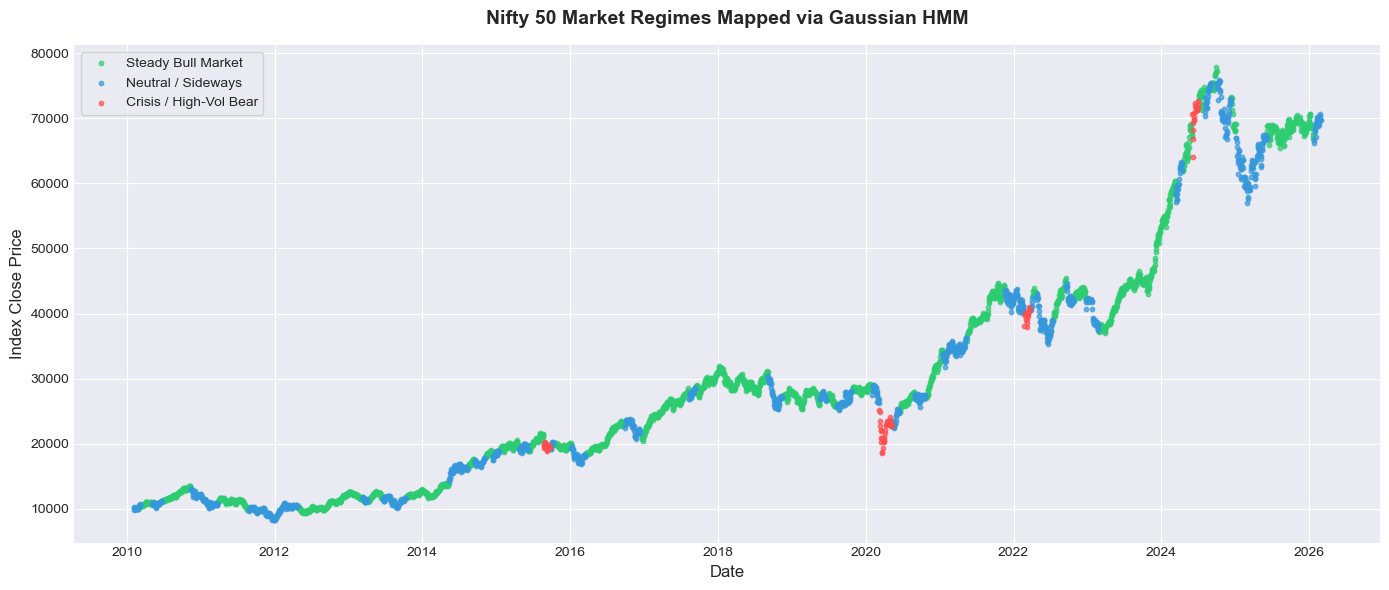

📈 Regime chart successfully generated and saved to 'production_ready_hmm_datasets/HMM_Market_Regimes_Chart.png'!


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set chart style
plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(14, 6))

# Map colors to regimes (0: Red/Crisis, 1: Green/Bull, 2: Blue/Neutral)
colors = {0: '#ff4d4d', 1: '#2ecc71', 2: '#3498db'}
regime_labels = {0: 'Crisis / High-Vol Bear', 1: 'Steady Bull Market', 2: 'Neutral / Sideways'}

for regime_id in [1, 2, 0]: # Plot bull first, then neutral, crisis on top
    subset = model_df[model_df['Regime'] == regime_id]
    ax.scatter(subset['Date'], subset['Close'], 
               c=colors[regime_id], label=regime_labels[regime_id], 
               s=10, alpha=0.7)

ax.set_title("Nifty 50 Market Regimes Mapped via Gaussian HMM", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Index Close Price", fontsize=12)
ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig('production_ready_hmm_datasets/HMM_Market_Regimes_Chart.png', dpi=300)
plt.show()
print("📈 Regime chart successfully generated and saved to 'production_ready_hmm_datasets/HMM_Market_Regimes_Chart.png'!")

HMM REGIME BACKTEST PERFORMANCE SUMMARY:
Benchmark (Buy & Hold) CAGR : 12.97% | Volatility: 17.95% | Sharpe: 0.72
HMM Strategy CAGR          : 13.01% | Volatility: 12.83% | Sharpe: 1.01


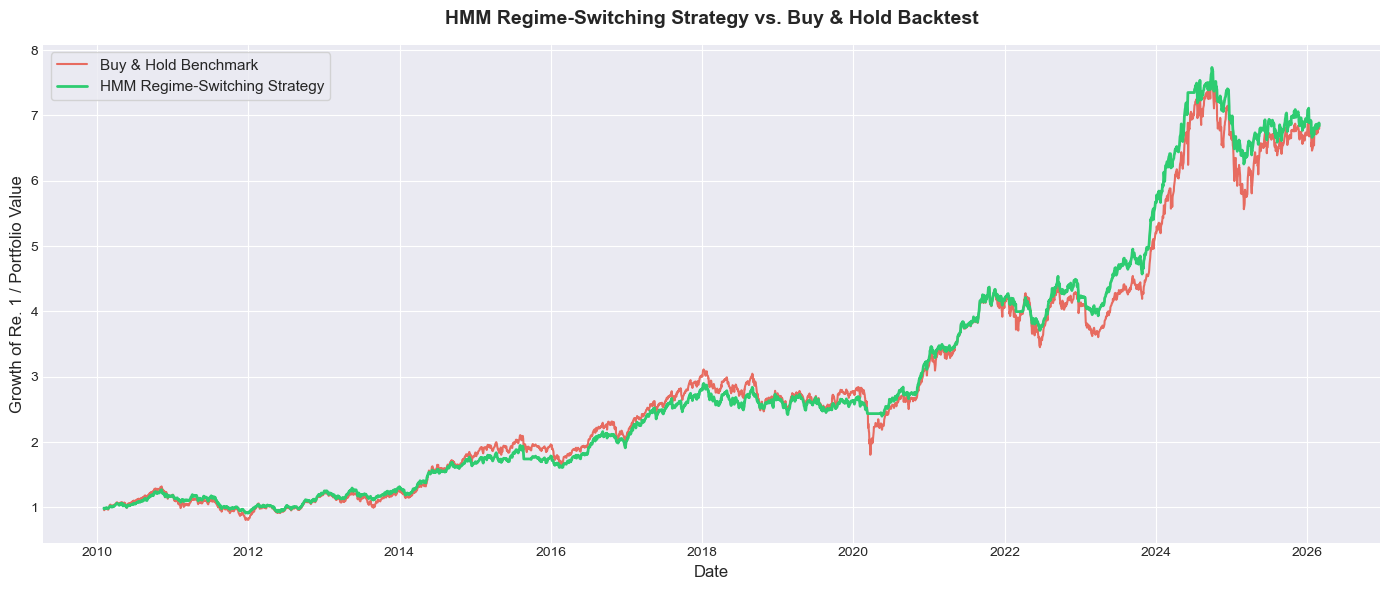

📈 Backtest performance chart saved to 'production_ready_hmm_datasets/HMM_Strategy_Backtest.png'!


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare strategy dataframe from our previous model run
backtest_df = model_df.copy()

# 2. Define Regime Allocation Rules
# Regime 1: Bull -> 100% Equity
# Regime 2: Neutral -> 50% Equity
# Regime 0: Crisis -> 0% Equity (Cash)
allocation_map = {1: 1.0, 2: 0.5, 0: 0.0}
backtest_df['Allocation'] = backtest_df['Regime'].map(allocation_map)

# 3. Calculate Strategy Returns vs. Buy & Hold Benchmark
# Strategy return = Previous day's allocation * Today's market return
backtest_df['Strategy_Return'] = backtest_df['Allocation'].shift(1) * backtest_df['Return']

# Drop NaN from shift
backtest_df = backtest_df.dropna(subset=['Strategy_Return']).reset_index(drop=True)

# 4. Compute Cumulative Returns
backtest_df['Benchmark_CumReturn'] = (1 + backtest_df['Return']).cumprod()
backtest_df['Strategy_CumReturn'] = (1 + backtest_df['Strategy_Return']).cumprod()

# 5. Calculate Performance Metrics
total_days = len(backtest_df)
years = total_days / 252

bench_cagr = (backtest_df['Benchmark_CumReturn'].iloc[-1] ** (1 / years)) - 1
strat_cagr = (backtest_df['Strategy_CumReturn'].iloc[-1] ** (1 / years)) - 1

bench_vol = backtest_df['Return'].std() * np.sqrt(252)
strat_vol = backtest_df['Strategy_Return'].std() * np.sqrt(252)

bench_sharpe = bench_cagr / bench_vol if bench_vol > 0 else 0
strat_sharpe = strat_cagr / strat_vol if strat_vol > 0 else 0

print("="*50)
print("HMM REGIME BACKTEST PERFORMANCE SUMMARY:")
print("="*50)
print(f"Benchmark (Buy & Hold) CAGR : {bench_cagr*100:.2f}% | Volatility: {bench_vol*100:.2f}% | Sharpe: {bench_sharpe:.2f}")
print(f"HMM Strategy CAGR          : {strat_cagr*100:.2f}% | Volatility: {strat_vol*100:.2f}% | Sharpe: {strat_sharpe:.2f}")
print("="*50)

# 6. Plot Backtest Performance Comparison
plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(backtest_df['Date'], backtest_df['Benchmark_CumReturn'], label='Buy & Hold Benchmark', color='#e74c3c', alpha=0.8, linewidth=1.5)
ax.plot(backtest_df['Date'], backtest_df['Strategy_CumReturn'], label='HMM Regime-Switching Strategy', color='#2ecc71', linewidth=2)

ax.set_title("HMM Regime-Switching Strategy vs. Buy & Hold Backtest", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Growth of Re. 1 / Portfolio Value", fontsize=12)
ax.legend(loc='upper left', frameon=True, fontsize=11)

plt.tight_layout()
plt.savefig('production_ready_hmm_datasets/HMM_Strategy_Backtest.png', dpi=300)
plt.show()
print("📈 Backtest performance chart saved to 'production_ready_hmm_datasets/HMM_Strategy_Backtest.png'!")

In [60]:
import os
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM

# 1. Load validated Nifty 50, India VIX, and Bond Yield datasets
nifty_path = os.path.join('production_ready_hmm_datasets', 'Nifty_50_Validated.csv')
vix_path = os.path.join('production_ready_hmm_datasets', 'India_VIX_Validated.csv')
bond_path = os.path.join('production_ready_hmm_datasets', 'Bond_Yield_Validated.csv')

df_nifty = pd.read_csv(nifty_path)
df_vix = pd.read_csv(vix_path)[['Date', 'Close']].rename(columns={'Close': 'VIX_Close'})
df_bond = pd.read_csv(bond_path)[['Date', 'Price']].rename(columns={'Price': 'Bond_Yield'})

# Ensure Date formatting
for d in [df_nifty, df_vix, df_bond]:
    d['Date'] = pd.to_datetime(d['Date'], errors='coerce')

# Merge datasets on Date
merged = df_nifty.merge(df_vix, on='Date', how='inner').merge(df_bond, on='Date', how='inner')
merged = merged.sort_values('Date').dropna().reset_index(drop=True)

# Engineer features: Return, Rolling Volatility, and VIX Level
merged['Return'] = merged['Close'].pct_change()
merged['Volatility'] = merged['Return'].rolling(window=20).std() * np.sqrt(252)
merged['VIX_Level'] = merged['VIX_Close']

model_multi = merged.dropna(subset=['Return', 'Volatility', 'VIX_Level']).reset_index(drop=True)

# 2. Extract multi-feature matrix X (Returns, Volatility, VIX)
X_multi = model_multi[['Return', 'Volatility', 'VIX_Level']].values

print("Fitting Multi-Feature HMM (Return, Volatility, VIX Level)...")
hmm_multi = GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)
hmm_multi.fit(X_multi)

# Predict multi-feature regimes
model_multi['Multi_Regime'] = hmm_multi.predict(X_multi)

print("\n" + "="*50)
print("MULTI-FEATURE HMM REGIME CHARACTERISTICS:")
print("="*50)
print(model_multi.groupby('Multi_Regime')[['Return', 'Volatility', 'VIX_Level']].mean())

Fitting Multi-Feature HMM (Return, Volatility, VIX Level)...

MULTI-FEATURE HMM REGIME CHARACTERISTICS:
                Return  Volatility  VIX_Level
Multi_Regime                                 
0             0.006279    1.781594  31.245189
1             0.001156    0.811018  20.191094
2             0.001531    0.537126  15.120622


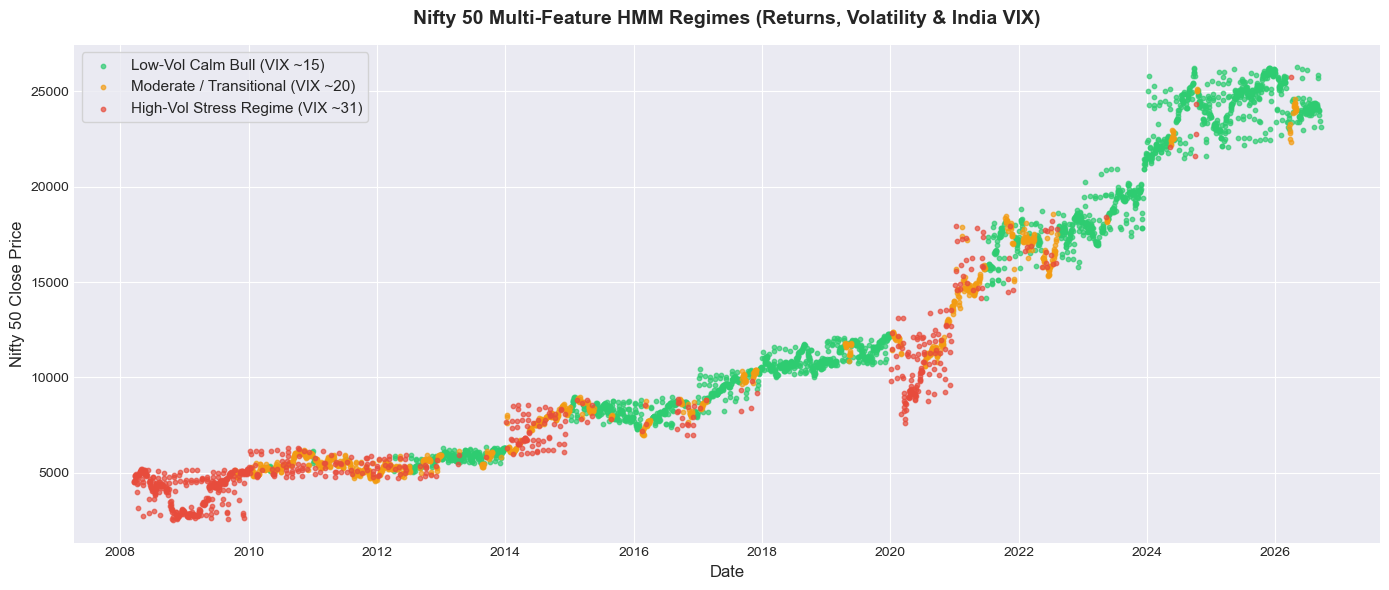

📈 Multi-feature regime chart saved successfully to 'production_ready_hmm_datasets/Multi_Feature_HMM_Regimes_Chart.png'!


In [61]:
# Let's write a script to plot and save the Multi-Feature HMM Regimes chart to tie everything together!
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(14, 6))

colors = {0: '#e74c3c', 1: '#f39c12', 2: '#2ecc71'}
regime_labels = {0: 'High-Vol Stress Regime (VIX ~31)', 1: 'Moderate / Transitional (VIX ~20)', 2: 'Low-Vol Calm Bull (VIX ~15)'}

for regime_id in [2, 1, 0]:
    subset = model_multi[model_multi['Multi_Regime'] == regime_id]
    ax.scatter(subset['Date'], subset['Close'], 
               c=colors[regime_id], label=regime_labels[regime_id], 
               s=10, alpha=0.7)

ax.set_title("Nifty 50 Multi-Feature HMM Regimes (Returns, Volatility & India VIX)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Nifty 50 Close Price", fontsize=12)
ax.legend(loc='upper left', frameon=True, fontsize=11)

plt.tight_layout()
chart_path = 'production_ready_hmm_datasets/Multi_Feature_HMM_Regimes_Chart.png'
plt.savefig(chart_path, dpi=300)
plt.show()
print(f"📈 Multi-feature regime chart saved successfully to '{chart_path}'!")

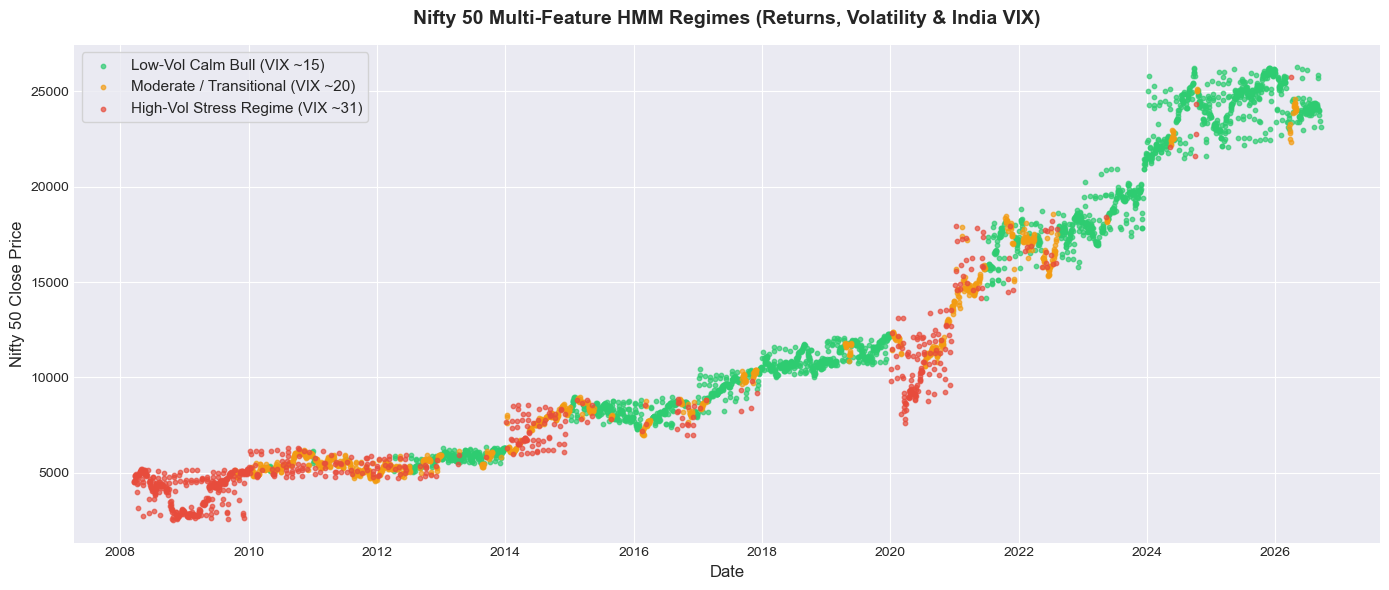

📈 Multi-feature regime chart saved successfully to 'production_ready_hmm_datasets/Multi_Feature_HMM_Regimes_Chart.png'!


In [62]:
import os
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

# 1. Load validated datasets
nifty_path = os.path.join('production_ready_hmm_datasets', 'Nifty_50_Validated.csv')
vix_path = os.path.join('production_ready_hmm_datasets', 'India_VIX_Validated.csv')
bond_path = os.path.join('production_ready_hmm_datasets', 'Bond_Yield_Validated.csv')

df_nifty = pd.read_csv(nifty_path)
df_vix = pd.read_csv(vix_path)[['Date', 'Close']].rename(columns={'Close': 'VIX_Close'})
df_bond = pd.read_csv(bond_path)[['Date', 'Price']].rename(columns={'Price': 'Bond_Yield'})

for d in [df_nifty, df_vix, df_bond]:
    d['Date'] = pd.to_datetime(d['Date'], errors='coerce')

merged = df_nifty.merge(df_vix, on='Date', how='inner').merge(df_bond, on='Date', how='inner')
merged = merged.sort_values('Date').dropna().reset_index(drop=True)

merged['Return'] = merged['Close'].pct_change()
merged['Volatility'] = merged['Return'].rolling(window=20).std() * np.sqrt(252)
merged['VIX_Level'] = merged['VIX_Close']

model_multi = merged.dropna(subset=['Return', 'Volatility', 'VIX_Level']).reset_index(drop=True)

X_multi = model_multi[['Return', 'Volatility', 'VIX_Level']].values
hmm_multi = GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)
hmm_multi.fit(X_multi)
model_multi['Multi_Regime'] = hmm_multi.predict(X_multi)

# 2. Plot and save chart
plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(14, 6))

colors = {0: '#e74c3c', 1: '#f39c12', 2: '#2ecc71'}
regime_labels = {0: 'High-Vol Stress Regime (VIX ~31)', 1: 'Moderate / Transitional (VIX ~20)', 2: 'Low-Vol Calm Bull (VIX ~15)'}

for regime_id in [2, 1, 0]:
    subset = model_multi[model_multi['Multi_Regime'] == regime_id]
    ax.scatter(subset['Date'], subset['Close'], 
               c=colors[regime_id], label=regime_labels[regime_id], 
               s=10, alpha=0.7)

ax.set_title("Nifty 50 Multi-Feature HMM Regimes (Returns, Volatility & India VIX)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Nifty 50 Close Price", fontsize=12)
ax.legend(loc='upper left', frameon=True, fontsize=11)

plt.tight_layout()
chart_path = 'production_ready_hmm_datasets/Multi_Feature_HMM_Regimes_Chart.png'
plt.savefig(chart_path, dpi=300)
plt.show()
print(f"📈 Multi-feature regime chart saved successfully to '{chart_path}'!")